In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Merged and deduplicated sentences (Ground Truth)
merged_ground_truth_sentences = [
    'great god sees beautiful city town',
    'father love mother heart life peace',
    'scribe write book upon papyrus scroll',
    'king give life stability power great',
    'man plow field like father do',
    'good god hear people heart peace',
    'strong man cut brick do house',
    'great cobra behind door bolt house',
    'mother gives birth youth beautiful heart',
    'king love feather truth maat peace',
    'old man hear book write scribe',
    'life become great like star sky',
    'god satisfy heart man do good',
    'river water ripple above lotus plant',
    'mighty king do strength force great',
    'servant give milk jar lord master',
    'heart become sweet like lotus plant',
    'scribe see star above horizon sky',
    'people hear authority king city town',
    'beautiful woman eat drink milk jar',
    'lord every people eat loaf bread',
    'soul ba emerge house sky star',
    'god love man do truth maat',
    'venerated father hear heart youth speak',
    'desert hare become food animal belly',
    'horizon sky emerge star god great',
    'mouth speak truth maat heart peace',
    'throne seat god king above mountain',
    'basket lord all people love god',
    'ka spirit emerge house life peace',
    'quail chick eat grain pellet hill desert stone',
    'adze cut stone make brick house gate',
    'snake fear head of bird sky storm fire',
    'chisel cut stone make throne seat temple',
    'seated man see mountain desert hill road town',
    'owl hear soul ba star sky horizon',
    'road city town master lord all king god',
    'fire above peace altar god great temple',
    'horned viper behind side rib stone brick house',
    'foot face upon road hill slope desert west',
    'milk jar give life youth strong heart',
    'pillar grandfather stability djed god king power authority',
    'eye see face upon sky horizon star',
    'reed shelter house man field town city',
    'lotus plant sweet like milk jar jar vessel',
    'placenta become life youth great power strength',
    'basket handle give offering peace altar god temple',
    'sickle cut grain pellet field man servant',
    'jars in rack house lord city town west',
    'three fox skins master lord all king strength',
    'heart satisfy peace truth maat life god deity',
    'swallow great emerge sky star mountain west',
    'hand do thing great strength force power',
    'stone brick make temple god great king',
    'papyrus clump riverbank lake water ripple lotus plant',
    'scarab become life heart man great god',
    'club strength force king city town house',
    'hoe plow field grain pellet man servant',
    'gate house opens life peace god heart',
    'twisted flax rope coil of rope thing make',
    'riverbank lotus plant swallow sky water ripple lake',
    'animal belly backbone heart soul ba ka spirit life',
    'servant offering milk jar loaf of bread lord peace',
    'city town gate brick house pillar grandfather stability',
    'west desert hill mountain stone horizon star',
    'feather truth maat authority power great mighty king',
    'writing scribe papyrus scroll book thing beautiful good',
    'sedge king papyrus clump plant lotus plant field riverbank',
    'forearm hand foot head of bird eye mouth',
    'storm fire fear god deity sky strong',
    'eat drink speak loaf of bread jar vessel milk jar',
    'adze chisel hoe sickle club strength force',
    'throne seated god king authority great mighty ring power',
    'above behind back face upon side rib underground horizon',
    'life ankh stability djed soul ba ka spirit star god',
    'cobra snake horned viper quail chick desert hare animal',
    'stool mat basket with handle ring vessel jar stone',
    'old man youth mother father gives birth begets servant',
    'temple god deity seated man seated woman people great',
    'single stroke stroke plural marker papyrus scroll writing scribe book',
    'road river lake mountain hill slope desert',
    'door bolt gate reed shelter brick house city town',
    'conical loaf give loaf of bread offering peace satisfy heart',
    'become scarab emerge life ankh horizon star',
    'senet board ring basket lord all city town house',
    'hear listen mouth eat drink speak truth maat feather',
    'tethering rope coil of rope rope twisted flax strength',
    'head of ox animal belly foot forearm backbone side',
    'quail chick swallow owl head of bird head ox desert',
    'thousand grain pellet thing great mighty god lord master',
    'heart sweet like lotus plant water ripple',
    'scribe write book thing beautiful good',
    'authority power strength force king he',
    'venerated father mother youth heart life',
    'riverbank papyrus clump plant lotus lake river',
    'become scarab great deity god king',
    'road city town house gate door bolt',
    'above underground horizon sky star mountain',
    'single stroke stroke plural marker papyrus scroll scribe book',
    'thousand grain pellet vessel jar offering',
    'stool mat basket with handle ring vessel',
    'hear listen authority king lord people',
    'eye see face upon road town',
    'horned viper cobra snake fear seated man',
    'conical loaf offering peace altar heart satisfy',
    'old man youth mother father gives birth',
    'head of ox animal belly heart life',
    'life ankh stability djed power authority great',
    'fire storm sky star moon horizon',
    'sedge king reed shelter house city town',
    'placenta become life youth great mighty',
    'hand do thing great strength force',
    'jars in rack vessel jar milk jar',
    'mouth speak truth maat heart peace satisfy',
    'quail chick swallow owl head of bird',
    'chisel adze stone brick house gate',
    'hoe plow field grain pellet food',
    'ba soul ka spirit emerge house life',
    'beautiful woman eat drink milk jar vessel',
    'tethering rope coil of rope rope twisted flax',
    'adze chisel stone brick city town house',
    'basket lord all people servant gate house',
    'cobra snake horned viper fear man woman',
    'desert hare animal belly backbone heart life',
    'eye face upon head of bird sky star',
    'father mother servant youth life peace altar',
    'feather truth maat god deity heart ba',
    'fire storm mountain hill slope desert hill',
    'gate door bolt reed shelter house brick',
    'authority power great mighty king strength force',
    'great big power strength force club hand',
    'hand forearm foot animal belly backbone rib',
    'hear listen mouth speak truth maat heart',
    'hoe plows tills field grain pellet servant',
    'horizon sky star mountain hill river lake',
    'jar vessel milk jar offering heart satisfy',
    'ka spirit ba soul emerge life horizon',
    'lake river riverbank water ripple lotus plant',
    'life ankh stability djed god authority power',
    'loaf of bread offering peace altar satisfy',
    'lotus plant papyrus clump reed leaf plant',
    'man woman youth servant people seated king',
    'old man seated woman people youth life',
    'papyrus scroll writing scribe book hand eye',
    'peace satisfy heart life soul ba god',
    'ring stool mat basket with handle jar',
    'road city town gate house brick stone',
    'scarab become to become life emerge star',
    'sickle cut grain pellet field servant man',
    'god / deity great / mighty above sky star horizon',
    'life (ankh) stability (djed) soul (ba) ka (spirit) heart peace / satisfy',
    'scribe writing / scribe book papyrus scroll papyrus clump eye',
    'father mother youth gives birth / begets life (ankh) peace / altar',
    'he / king sedge (king) throne authority power great / mighty',
    'stone brick adze chisel to do / make house',
    'grain / pellet milk jar vessel jar eat / drink / speak thing',
    'river riverbank water ripple lotus plant lake swallow',
    'animal belly backbone side / rib heart soul (ba) life (ankh)',
    'mountain desert hill desert hill slope road city / town',
    'quail chick swallow head of bird head of ox owl eye',
    'gate door bolt reed shelter brick house city / town',
    'stool / mat basket with handle ring vessel jar stone',
    'conical loaf (give) offering peace / altar peace / content (satisfied) heart',
    'hand forearm foot animal belly backbone heart',
    'mouth eat / drink / speak feather (truth/maat) heart peace / satisfy life (ankh)',
    'field plant grain / pellet hoe plows (tills) servant',
    'tethering rope coil of rope twisted flax rope ring thing',
    'thousand thing great / big great / mighty god / deity lord / every',
    'beautiful / good woman youth seated woman mother heart',
    'venerated / marrow father youth old man life (ankh) peace / satisfy',
    'three fox skins strength / force power authority king he / king',
    'senet board ring thing to do / make hand eye',
    'placenta become to become life (ankh) emerge star',
    'fire storm sky star horizon mountain desert hill',
    'above behind / back face / upon side / rib underground horizon',
    'single stroke stroke (plural marker) papyrus scroll book writing / scribe thing',
    'seated god / king god / deity great / mighty master (lord) / all (every) king',
    'lake river water ripple lotus plant swallow owl',
    'sweet like / as (or example) lotus plant milk jar heart',
    'conical loaf (give) offering peace / satisfy heart god / deity lord / every',
    'thousand grain / pellet vessel jar offering god / deity',
    'tethering rope coil of rope rope twisted flax ring thing',
    'placenta become to become life (ankh) youth man',
    'senet board seated man seated woman house life (ankh) peace / content (satisfied)',
    'head of bird head of ox animal belly backbone side / rib placenta',
    'ka (spirit) ba (soul) emerge house city / town sky',
    'loaf of bread milk jar vessel jar offering peace / altar',
    'hoe plows (tills) grain / pellet field servant man',
    'sickle cut grain / pellet lotus plant hand basket with handle',
    'throne seat / throne god / deity king great / big mighty',
    'stool / mat ring basket with handle jar brick stone',
    'storm fire above mountain desert hill sky',
    'door bolt gate house city / town town road',
    'sky horizon star above mountain desert hill',
    'quail chick swallow owl head of bird head of ox animal belly',
    'he / king throne authority power strength / force great / mighty',
    'writing / scribe book papyrus scroll hand eye mouth',
    'heart peace / satisfy life (ankh) soul (ba) ka (spirit) god / deity',
    'river riverbank lake water ripple lotus plant swallow',
    'old man seated woman people servant seated man youth',
    'lotus plant papyrus clump reed leaf plant field riverbank',
    'chisel adze stone brick temple gate building',
    'negation (no/not) fear god / deity heart peace / satisfy',
    'to return / retreat road city / town house life (ankh)',
    'to do / make offering peace / altar god / deity temple',
    'to become scarab emerge horizon sky life (ankh)',
    'to give conical loaf (give) offering peace / altar satisfy',
    'pillar / grandfather stability (djed) backbone ka (spirit) life (ankh)',
    'club strength / force power hand forearm back',
    'mother gives birth / begets youth beautiful / good heart life (ankh)',
    'venerated / marrow old man seated man seated woman youth',
    'negation (no/not) hear / listen authority king city / town',
    'hill slope desert hill mountain road town city / town',
    'milk jar jars in rack vessel jar loaf of bread',
    'heart love mother father youth beautiful / good',
    'to do / make house brick stone adze chisel gate',
    'sedge (king) he / king throne seat / throne authority power',
    'papyrus clump field lake river riverbank water ripple',
    'fire storm star sky horizon above mountain',
    'scribe writing / scribe papyrus scroll hand eye heart',
    'tethering rope rope coil of rope basket with handle thing',
    'single stroke stroke (plural marker) thing great / big great / mighty',
    'lotus plant plant reed leaf papyrus clump lake water ripple',
    'door bolt gate house brick stone city / town',
    'seated god / king authority great / mighty master (lord) / all (every)',
    'mouth eat / drink / speak heart sweet like / as (or example)',
    'eye sees face / upon road mountain desert hill',
    'animal belly backbone side / rib placenta heart life (ankh)',
    'basket (lord / all) people hear / listen authority king god / deity',
    'sky above mountain desert hill horizon star star',
    'chisel adze cut stone brick house building',
    'old man youth servant people seated man woman',
    'three fox skins strength / force power authority king',
    'senet board ring thing to do / make hand',
    'placenta become to become life (ankh) youth great / mighty',
    'adze chisel cut brick stone gate house',
    'venerated / marrow father mother youth life (ankh) peace / satisfy',
    'conical loaf (give) offering peace / satisfy heart god / deity',
    'quail chick swallow owl head of bird animal belly',
    'tethering rope coil of rope twisted flax ring thing',
    'single stroke stroke (plural marker) thing writing / scribe book',
    'mouth eat / drink / speak feather (truth/maat) heart peace / satisfy',
    'hoe plows (tills) field grain / pellet servant man',
    'riverbank papyrus clump plant lotus plant lake river',
    'seated god / king god / deity great / mighty master (lord) / all (every)',
    'hand forearm foot side / rib backbone heart',
    'basket with handle jar vessel milk jar jars in rack',
    'become scarab emerge life (ankh) horizon star sky',
    'chisel adze cut stone brick temple gate',
    'conical loaf (give) offering peace / altar peace / satisfy heart',
    'door bolt gate reed shelter brick house town',
    'eat / drink / speak loaf of bread milk jar vessel jar',
    'father mother youth gives birth / begets life (ankh) peace / satisfy',
    'feather (truth/maat) god / deity heart ba (soul) ka (spirit) life (ankh)',
    'hand forearm foot animal belly backbone side / rib',
    'hear / listen mouth eat / drink / speak truth / maat feather (truth/maat)',
    'heart sweet like / as (or example) lotus plant milk jar',
    'adze chisel cut stone building gate',
    'animal belly backbone side / rib placenta heart life',
    'authority power great / mighty king he / king sedge (king)',
    'beautiful / good woman love youth heart peace / satisfy',
    'become scarab to become emerge horizon sky',
    'book papyrus scroll writing / scribe hand eye mouth',
    'chisel adze cut brick stone house gate',
    'city / town town road riverbank lake river',
    'conical loaf (give) to give offering peace / satisfy god',
    'desert hare (to be) animal belly food eat / drink / speak',
    'door bolt gate reed shelter house brick city / town',
    'father mother gives birth / begets youth life / ankh',
    'feather (truth/maat) heart peace / content (satisfied) god / deity lord',
    'field grain / pellet hoe plows (tills) servant man',
    'fire storm above mountain desert hill sky horizon',
    'foot forearm hand side / rib backbone heart',
    'gate house brick stone city / town town',
    'great / big great / mighty power authority king he',
    'hear / listen mouth eat / drink / speak truth / maat feather',
    'heart sweet like / as (or example) lotus plant water ripple',
    'jar jars in rack vessel jar milk jar offering',
    'ka (spirit) ba (soul) emerge house city / town life',
    'life (ankh) stability (djed) god authority power great / mighty god',
    'lotus plant plant reed leaf papyrus clump lake riverbank',
    'quail chick swallow owl head of bird head of ox',
    'single stroke stroke (plural marker) thing writing / scribe book papyrus scroll',
    'twisted flax rope coil of rope ring thing hand',
    'master (lord) / all (every) king he / king authority power great / mighty',
    'vessel jar milk jar jars in rack offering peace / satisfy',
    'head of bird head of ox animal belly heart soul (ba) life (ankh)',
    'three fox skins strength / force power authority king god / deity',
    'senet board ring basket (lord / all) thing to do / make hand',
    'placenta become to become life (ankh) youth beautiful / good',
    'venerated / marrow father mother youth heart peace / content (satisfied)',
    'negation (no/not) speak thing heart feather (truth/maat) god / deity',
    'to return / retreat road mountain desert hill desert hill slope',
    'single stroke stroke (plural marker) papyrus scroll book scribe writing / scribe',
    'quail chick swallow owl head of bird head of ox animal',
    'mouth eat / drink / speak loaf of bread milk jar vessel',
    'chisel adze cut stone brick house city / town',
    'gate door bolt reed shelter brick house building town',
    'fire storm star sky horizon above mountain desert hill',
    'sedge (king) he / king throne seat / throne authority power strength / force',
    'lotus plant papyrus clump reed leaf plant field lake',
    'hoe plows (tills) plows (repeated) field grain / pellet servant man',
    'heart love mother father youth life (ankh) peace / satisfy',
    'eye sees face / upon head of bird sky star',
    'ba (soul) ka (spirit) emerge house city / town horizon sky',
    'thousand grain / pellet thing great / big great / mighty god / deity',
    'stool / mat basket with handle ring vessel jar milk jar',
    'beautiful / good woman youth seated woman mother heart life (ankh)',
    'life (ankh) stability (djed) power authority great / mighty master (lord) / all (every)',
    'river riverbank lake water ripple lotus plant swallow owl',
    'conical loaf (give) to give offering peace / altar god / deity lord / every',
    'hand forearm foot side / rib backbone heart soul (ba)',
    'riverbank river lake water ripple swallow head of bird',
    'hoe plows (tills) field plant grain / pellet thousand',
    'gate door bolt house brick stone town road',
    'authority power great / mighty master (lord) / all (every) god / deity',
    'beautiful / good mother gives birth / begets youth life (ankh) heart',
    'chisel adze to do / make stone brick temple building',
    'eye face / upon head of ox animal belly heart',
    'father mother youth seated man seated woman house life (ankh)',
    'feather (truth/maat) truth / maat heart peace / satisfy god / deity lord',
    'fire storm sky horizon above mountain desert hill desert hill',
    'hand forearm foot side / rib backbone ka (spirit) ba (soul)',
    'hear / listen mouth speak truth / maat feather (truth/maat) heart peace / satisfy',
    'he / king sedge (king) throne seat / throne authority power strength / force',
    'lotus plant papyrus clump reed leaf plant field riverbank lake',
    'milk jar vessel jar jars in rack offering peace / altar',
    'negation (no/not) do / make thing beautiful / good heart fear',
    'old man youth servant people city / town town road',
    'papyrus scroll writing / scribe book hand single stroke stroke (plural marker)',
    'scarab become to become life (ankh) emerge star sky',
    'sky star horizon above mountain desert hill desert hill slope',
    'stability (djed) pillar / grandfather power authority great / mighty life (ankh)',
    'stool / mat ring basket with handle jar brick stone house',
    'tethering rope twisted flax rope coil of rope ring thing',
    'thousand grain / pellet offering conical loaf (give) god / deity lord',
    'to return / retreat road city / town house gate door bolt',
    'venerated / marrow father youth life (ankh) peace / content (satisfied) heart',
    'woman beautiful / good heart love mother youth life (ankh)',
    'servant hoe plows (tills) field grain / pellet food',
    'scribe writing / scribe papyrus scroll book beautiful / good thing',
    'old man venerated / marrow father youth life (ankh) peace / satisfy',
    'mother gives birth / begets youth heart love beautiful / good',
    'king he / king sedge (king) authority power great / mighty ring',
    'god / deity seated god / king great / mighty master (lord) / all (every) thousand',
    'mouth speak truth / maat feather (truth/maat) hear / listen heart',
    'eye sees face / upon sky star horizon above',
    'hand to do / make thing great / big strength / force power',
    'adze chisel cut stone brick temple house building',
    'gate door bolt reed shelter brick house city / town town',
    'road riverbank lake water ripple lotus plant papyrus clump',
    'animal belly backbone side / rib placenta heart soul (ba) life (ankh)',
    'fire storm above mountain desert hill desert hill slope sky',
    'to become scarab emerge horizon star sky life (ankh) peace / satisfy',
    'to return / retreat road mountain desert hill desert hill city / town',
    'negation (no/not) fear storm fire god / deity heart strength / force',
    'conical loaf (give) offering peace / altar loaf of bread milk jar jar',
    'jars in rack vessel jar milk jar basket with handle ring',
    'stool / mat basket with handle ring thing to do / make hand',
    'tethering rope twisted flax rope coil of rope ring vessel',
    'single stroke stroke (plural marker) papyrus scroll book scribe writing / scribe thing',
    'stability (djed) pillar / grandfather ka (spirit) ba (soul) life (ankh) god / deity',
    'thousand grain / pellet field plant lotus plant reed leaf',
    'beautiful / good woman seated woman mother heart love life (ankh)',
    'three fox skins strength / force power authority king he / king sedge (king)',
    'senet board ring thing to do / make hand seated man',
    'sickle cut grain / pellet field servant man hoe plows (tills)',
    'above behind / back face / upon side / rib underground horizon sky',
    'to return / retreat road riverbank water ripple lotus plant',
    'negation (no/not) hear / listen mouth speak truth / maat feather (truth/maat)',
    'to become scarab emerge life (ankh) soul (ba) ka (spirit)',
    'placenta animal belly backbone side / rib head of ox',
    'venerated / marrow father mother youth gives birth / begets life (ankh)',
    'three fox skins strength / force club power authority king',
    'senet board ring thing to do / make hand forearm',
    'single stroke stroke (plural marker) papyrus scroll scribe writing / scribe book',
    'thousand grain / pellet offering conical loaf (give) peace / altar',
    'adze chisel cut stone brick building temple',
    'gate door bolt reed shelter house city / town town',
    'fire storm above sky star horizon mountain',
    'hoe plows (tills) field grain / pellet servant man people',
    'life (ankh) stability (djed) pillar / grandfather power authority great / mighty',
    'conical loaf (give) to give offering peace / satisfy heart god',
    'hand forearm foot side / rib backbone heart life (ankh)',
    'mouth eat / drink / speak loaf of bread milk jar vessel jar',
    'scribe writing / scribe book papyrus scroll beautiful / good thing',
    'writing / scribe papyrus scroll book thing beautiful / good heart',
    'jars in rack vessel jar milk jar basket with handle stool / mat',
    'conical loaf (give) loaf of bread offering peace / satisfy heart satisfy',
    'adze chisel to do / make stone brick building house',
    'road riverbank lake river water ripple lotus plant plant',
    'animal belly backbone side / rib placenta heart life (ankh) ka (spirit)',
    'to become scarab emerge life (ankh) soul (ba) ka (spirit) star',
    'to return / retreat road mountain desert hill desert hill slope town',
    'negation (no/not) do / make thing fear god / deity king lord',
    'thousand grain / pellet field plant reed leaf papyrus clump lotus',
    'single stroke stroke (plural marker) papyrus scroll book scribe writing / scribe eye',
    'stability (djed) pillar / grandfather authority power great / mighty life (ankh) king',
    'beautiful / good woman seated woman mother gives birth / begets youth heart',
    'three fox skins strength / force power authority king he / king sedge',
    'senet board ring thing to do / make hand forearm foot',
    'above behind / back face / upon side / rib underground horizon star',
    'venerated / marrow father youth old man life (ankh) peace / satisfy people',
    'hand forearm foot side / rib backbone heart soul (ba) spirit',
    'mouth eat / drink / speak truth / maat feather (truth/maat) hear / listen satisfy',
    'eye sees face / upon head of bird sky star horizon',
    'ba (soul) ka (spirit) emerge house life (ankh) horizon sky star',
    'throne seat / throne god / deity king authority power great / mighty',
    'river riverbank lake water ripple lotus plant swallow owl',
    'old man youth servant people seated man woman father mother',
    'negation (no/not) return / retreat road city / town house life (ankh)',
    'twisted flax rope coil of rope ring vessel jar stone',
    'single stroke stroke (plural marker) thing writing / scribe book scribe',
    'thousand grain / pellet vessel jar offering peace / satisfy heart',
    'adze chisel cut stone brick building temple god / deity',
    'hoe plows (tills) field grain / pellet servant man people youth',
    'ba (soul) ka (spirit) emerge house city / town horizon sky star',
    'life (ankh) stability (djed) pillar / grandfather power authority great / mighty king',
    'conical loaf (give) to give offering peace / satisfy heart god deity',
    'scribe writing / scribe book papyrus scroll beautiful / good thing heart',
    'thousand grain / pellet hoe plows (tills) field servant',
    'vessel jar milk jar jars in rack stool / mat',
    'conical loaf (give) offering peace / satisfy heart sweet like / as (or example)',
    'beautiful / good woman mother gives birth / begets youth life (ankh)',
    'old man venerated / marrow father youth heart peace / satisfy',
    'negation (no/not) return / retreat road city / town gate house',
    'scribe writing / scribe book papyrus scroll hand eye mouth',
    'adze chisel cut stone brick temple god / deity',
    'sickle cut grain / pellet field servant man people youth',
    'single stroke stroke (plural marker) thing writing / scribe book scribe papyrus',
    'thousand grain / pellet offering conical loaf (give) peace / satisfy',
    'stool / mat mat (repeated) stool / mat (repeated) basket with handle ring vessel',
    'tethering rope twisted flax coil of rope rope ring thing',
    'mouth eat / drink / speak loaf of bread milk jar jar',
    'animal belly backbone side / rib placenta heart life (ankh) spirit',
    'to do / make house brick stone building temple gate door bolt',
    'the god gives life to people',
    'the king loves beautiful city town',
    'father and mother give life',
    'the great god hears people',
    'man eats bread and drinks',
    'the god sits upon throne',
    'people live beside river bank',
    'the king has great power',
    'woman gives birth to youth',
    'the god opens the gate',
    'the heart fears great storm',
    'the god sees all people',
    'man walks road beside river',
    'the city has great temple',
    'the god brings peace content satisfied',
    'people offer bread to god',
    'the king rules city town',
    'man works field with hoe',
    'the sun rises on horizon',
    'the god grants life ankh',
    'people gather grain in jars',
    'the king sits on throne',
    'the soul ba leaves body',
    'man hears voice of god',
    'the god lives in temple',
    'people cross river by boat',
    'the king has strong backbone',
    'man builds house from brick',
    'the god loves truth maat',
    'people walk road to town',
    'the god emerges from horizon',
    'man drinks water from jar',
    'the king gives offering to god',
    'people live under open sky',
    'the god grants peace to people',
    'man plows field with sickle',
    'the king wears crown of sedge',
    'people fear power of god',
    'the god watches over people',
    'man rests on stool mat',
    'the king hears prayer of people',
    'the god brings stability djed',
    'people gather at temple gate',
    'the god gives strength force',
    'man follows road to temple',
    'the king commands servant people',
    'the god sees heart of man',
    'the god lives beyond western horizon',
    'the king gives bread offering people',
    'man sees star above desert',
    'the god emerges from underground lake',
    'people gather beside riverbank gate',
    'woman sits upon stool mat',
    'the king holds power authority',
    'man opens door bolt house',
    'the god hears heart of people',
    'people walk behind backbone mountain',
    'the god grants sweet life ankh',
    'man eats loaf of bread',
    'the king rules above city town',
    'people fear strong snake cobra',
    'the god brings peace altar temple',
    'man carries basket with handle',
    'the king sees all people',
    'people drink water ripple river',
    'the god loves beautiful good truth',
    'man rests beside fire lake',
    'the king commands servant man',
    'people follow road across desert',
    'the god opens gate horizon',
    'man works plows tills field',
    'the king sits seat throne',
    'people give offering to temple',
    'the god watches over city',
    'man hears owl at night',
    'the king holds crook club',
    'people cross river at gate',
    'the god gives strength force power',
    'man follows king to town',
    'the king protects people city',
    'people gather grain pellet field',
    'the god dwells within temple',
    'man carries jar milk jar',
    'the king speaks words of power',
    'people see star in sky',
    'the god grants stability djed',
    'man rests beneath lotus plant',
    'the king stands above people',
    'people honor god with offering',
    'the god brings life to man',
    'man walks road beside mountain',
    'the king hears voice of god',
    'people live near riverbank town',
    'the god rises above eastern horizon',
    'the king gives power to people',
    'man carries basket lord all',
    'people live behind desert hill',
    'the god hears prayer in temple',
    'woman drinks milk from jar',
    'the king holds seat throne stability',
    'man follows road beside riverbank',
    'people fear authority of king',
    'the god grants peace satisfy heart',
    'man eats grain pellet bread',
    'the king rules with strength force',
    'people walk toward city gate',
    'the god opens door bolt',
    'man rests under reed shelter',
    'the king wears crown sedge',
    'people see god upon horizon',
    'the god gives life ka',
    'man hears voice from mouth',
    'people gather at peace altar',
    'the king sits seated man',
    'the god watches star in sky',
    'man works field near river',
    'people offer loaf of bread',
    'the god grants sweet peace',
    'man carries rope coil rope',
    'people cross road through town',
    'the god dwells beyond west',
    'man rests beside stone pillar',
    'the king gives offering temple',
    'people honor feather truth maat',
    'the god gives strong backbone',
    'man follows behind king authority',
    'people see light on horizon',
    'the god lives in sky',
    'man drinks water ripple lake',
    'the king protects city people',
    'people gather under lotus plant',
    'the god opens path road',
    'man hears sound of owl',
    'the king rules above all',
    'people live beside mountain hill',
    'the god grants power authority',
    'man stands before temple gate',
    'the king sees heart of people',
    'people rest beneath open sky',
    'god gives life ankh people',
    'king holds power authority strength force',
    'man walks road toward city town',
    'people gather grain pellet jars rack',
    'woman gives birth begets youth',
    'god emerges above horizon sky',
    'king sits throne seat stability',
    'man drinks water ripple river',
    'people fear storm desert hill',
    'god grants peace content satisfied',
    'man plows tills field hoe',
    'king hears people speak mouth',
    'people live beside riverbank lake',
    'god watches star swallow sky',
    'king gives offering temple god',
    'people follow road behind mountain',
    'god gives strength force backbone',
    'king protects city town people',
    'god opens gate horizon west',
    'man hears owl night sky',
    'king rules above lord every',
    'people gather lotus plant lake',
    'god grants life ka spirit',
    'king gives bread loaf offering',
    'man eats drinks speak mouth',
    'people live near city town',
    'woman carries water ripple jar',
    'god rises from desert horizon',
    'king holds throne seat power',
    'man walks behind mountain hill',
    'people fear snake horned viper',
    'god opens house door bolt',
    'man rests beside fire stone',
    'king hears heart of people',
    'people gather under sky star',
    'god gives strength force man',
    'man works field plows repeated',
    'king rules people city town',
    'people drink lake water ripple',
    'god watches river riverbank west',
    'man carries rope twisted flax',
    'king protects temple gate people',
    'people honor god deity temple',
    'god grants stability djed pillar',
    'man follows road toward horizon',
    'king sits seated god throne',
    'people live beside desert hill',
    'god gives birth begets life people',
    'king holds crook club authority power',
    'man hears listen heart mouth god',
    'people cross riverbank road town gate',
    'woman sits seated woman stool mat',
    'god opens exists found house gate',
    'king rules above lord every people',
    'man cuts stone chisel forearm hand',
    'people gather papyrus clump reed leaf',
    'god dwells underground mountain west horizon',
    'king sees eye heart people god',
    'man carries vessel milk jar hand',
    'people fear desert hare be hill',
    'storm fire above sky god mountain',
    'king sits seat throne stability djed',
    'man sees swallow great sky star',
    'reed shelter house people town city',
    'god gives thousand grain pellet people',
    'king power authority servant people god',
    'man plows repeated field hoe hand',
    'people honor venerated marrow pillar god',
    'god soul ba sky life ankh',
    'ring throne seat king power authority',
    'man sees head bird owl sky',
    'people eat drink speak mouth heart',
    'god gives life people power',
    'king holds authority strength force',
    'man walks road town gate',
    'people gather grain field jars',
    'woman gives birth youth life',
    'god emerges horizon sky west',
    'king sits throne stability djed',
    'man drinks water river lake',
    'god grants peace satisfied heart',
    'man plows field hoe sickle',
    'king hears people mouth heart',
    'people live riverbank city town',
    'god watches star sky swallow',
    'man rests reed shelter house',
    'people follow road mountain hill',
    'god gives backbone strength power',
    'man carries basket handle rope',
    'king protects city people power',
    'people honor truth maat feather',
    'man hears owl sky night',
    'king rules lord every people',
    'god grants power authority king people',
    'king hears prayer temple people god',
    'man walks road riverbank west horizon',
    'people gather offering temple gate peace',
    'woman carries milk jar house life',
    'god rises sky star horizon west',
    'king sits throne seat stability power',
    'man drinks water ripple vessel jar',
    'people fear snake cobra desert hill',
    'god gives life ankh ka spirit',
    'man plows tills field grain pellet',
    'king rules city town people power',
    'people live river lake field house',
    'god watches soul ba sky star',
    'man rests stool mat house peace',
    'king gives bread loaf people offering',
    'people follow road gate city town',
    'god opens house gate door bolt',
    'man carries rope coil twisted flax',
    'king protects temple god people city',
    'people honor god deity power authority',
    'god grants stability djed pillar strength',
    'man hears owl swallow sky star',
    'king rules lord every thousand people',
    'people gather papyrus scroll writing scribe',
    'god grants life power people',
    'king holds authority backbone strength force',
    'man walks road desert hill',
    'people gather grain pellet offering',
    'woman gives birth placenta life',
    'god emerges underground mountain west',
    'king sits throne seat power',
    'man drinks water ripple riverbank',
    'people fear fire storm sky',
    'god grants peace altar temple',
    'man plows tills field sickle',
    'king hears mouth speak people',
    'people live house city town',
    'god watches star sky west',
    'man rests reed shelter mat',
    'king gives offering loaf bread',
    'people follow road gate town',
    'god opens exists found house',
    'man carries vessel jar hand',
    'king protects people city authority',
    'god grants stability djed power',
    'people gather lotus plant river',
    'god gives life power authority',
    'king holds throne stability djed power',
    'man walks road mountain west horizon',
    'people gather offering bread loaf',
    'woman drinks milk jar life',
    'god rises sky horizon star',
    'man plows field grain pellet',
    'people fear snake cobra storm',
    'man rests house reed shelter',
    'king gives power authority people',
    'people live riverbank field house',
    'god watches sky star swallow',
    'man carries basket handle grain',
    'king rules city people power',
    'people follow road desert town',
    'god opens gate house west',
    'man drinks water ripple vessel',
    'king protects temple people god',
    'people honor god truth maat',
    'god grants strength force backbone',
    'man hears owl night west',
    'king rules lord every thousand',
    'people gather papyrus clump writing',
    'god gives power authority people king',
    'king sits throne seat stability djed',
    'man walks road beside riverbank town',
    'people gather offering peace altar temple',
    'woman carries milk jar life youth',
    'god emerges horizon west sky star',
    'king hears heart mouth people god',
    'man plows field grain pellet sickle',
    'people fear storm fire desert hill',
    'god grants life ankh ka spirit',
    'man rests house reed shelter peace',
    'people follow road gate temple city',
    'god watches soul ba sky west',
    'king protects god temple people city',
    'god opens gate house horizon west',
    'man hears owl swallow night sky',
    'god grants power strength force backbone',
    'king holds authority lord every people',
    'man walks road toward west horizon',
    'people gather grain pellet thousand',
    'woman gives life placenta youth',
    'god emerges underground lake mountain',
    'king sits throne stability pillar djed',
    'man drinks water ripple jar',
    'people fear horned viper snake',
    'god grants peace satisfy heart',
    'king hears voice mouth people',
    'people live beside riverbank field',
    'man rests stool mat house',
    'king gives offering bread loaf',
    'people follow road mountain desert',
    'god opens gate town city',
    'man carries vessel jar milk',
    'king protects people power authority',
    'god grants life ankh ka',
    'king rules city town lord',
    'people gather papyrus scroll writing',
    'god gives power strength force people',
    'king sits throne power authority stability',
    'man walks road city town gate',
    'people gather offering bread loaf temple',
    'woman gives birth life youth placenta',
    'god emerges horizon sky star west',
    'king hears people speak mouth heart',
    'man plows field grain pellet hoe',
    'people fear desert storm fire hill',
    'god grants peace altar content satisfied',
    'man rests house stool mat peace',
    'king rules people city town power',
    'people follow road gate temple town',
    'man carries basket handle grain pellet',
    'king protects temple god people authority',
    'people honor truth maat feather god',
    'god opens gate house town city',
    'man hears owl sky star night',
    'god gives strength force backbone power',
    'king holds throne authority lord every',
    'man walks road river lake west',
    'people gather grain pellet thousand jars',
    'woman carries placenta life youth birth',
    'god emerges desert hill horizon sky',
    'king hears voice heart people god',
    'man drinks water ripple lake jar',
    'people fear storm fire sky west',
    'god grants peace altar temple satisfied',
    'man rests reed shelter house mat',
    'king rules city town authority power',
    'people follow road mountain hill desert',
    'god watches star sky swallow west',
    'man carries basket lord all grain',
    'king protects people servant authority power',
    'people honor god deity temple offering',
    'god opens gate city town house',
    'man hears owl night desert sky',
    'king rules lord every people thousand',
    'king holds power authority strength',
    'man walks road town city',
    'god emerges horizon west sky',
    'people fear snake cobra desert',
    'god opens gate house town',
    'king protects people city power',
    'god grants authority power strength force',
    'king holds seat throne stability pillar',
    'man walks road desert west horizon',
    'people gather jars rack grain pellet',
    'woman carries milk jar house',
    'god emerges underground west mountain',
    'king hears voice heart god people',
    'people fear storm fire sky',
    'man plows field sickle grain',
    'king rules lord every authority',
    'people live riverbank lake field',
    'man rests stool mat peace',
    'king gives offering peace altar',
    'people follow road mountain west',
    'god opens gate temple city',
    'man carries rope coil flax',
    'king protects people strength power',
    'king holds crook club power authority',
    'man walks road riverbank lake west',
    'woman sits seated woman house peace',
    'god emerges from lake horizon sky',
    'king hears voice mouth heart god',
    'people fear horned viper desert hill',
    'god grants stability djed strength force',
    'man plows repeated field grain pellet',
    'king rules city town servant people',
    'people live beside mountain hill desert',
    'god watches soul ba horizon west',
    'man rests under lotus plant peace',
    'king gives offering milk jar temple',
    'god opens gate underground west horizon',
    'king protects people god temple authority',
    'god grants life ka soul',
    'king holds authority power backbone strength',
    'man walks road mountain hill west',
    'woman gives birth placenta youth life',
    'god emerges horizon sky swallow star',
    'king sits throne seat power stability',
    'man drinks water ripple lake river',
    'people fear storm fire desert sky',
    'god grants peace altar temple content',
    'man plows tills field grain sickle',
    'king hears mouth speak heart people',
    'people live beside lake riverbank field',
    'god watches star sky horizon west',
    'man rests reed shelter stool mat',
    'king gives offering grain pellet temple',
    'people follow road desert mountain hill',
    'god opens gate town city house',
    'man carries vessel jar milk hand',
    'king protects people authority strength power',
    'god gives power authority strength backbone',
    'king holds throne seat stability pillar',
    'man walks road desert hill west',
    'people gather grain pellet field jars',
    'woman carries milk jar youth life',
    'god emerges horizon sky star swallow',
    'king hears heart voice people god',
    'man drinks water ripple riverbank lake',
    'people fear horned viper snake desert',
    'god grants peace altar temple satisfy',
    'man plows tills field hoe grain',
    'king rules city town power authority',
    'people live beside mountain hill field',
    'god watches soul ba sky horizon',
    'man rests under lotus plant mat',
    'king gives offering bread loaf temple',
    'people follow road gate town city',
    'god opens gate west underground horizon',
    'man carries rope twisted flax hand',
    'king protects god temple people power',
    'god grants strength force power backbone',
    'king holds authority lord every thousand',
    'man walks road river west horizon',
    'people gather grain pellet lake field',
    'woman gives life youth placenta birth',
    'god emerges sky horizon west mountain',
    'king sits throne seat pillar stability',
    'man drinks water ripple jar vessel',
    'people fear fire storm sky desert',
    'man plows repeated field hoe grain',
    'king hears heart voice mouth people',
    'people live beside field riverbank lake',
    'god watches star swallow sky west',
    'king gives offering grain pellet god',
    'people follow road desert west horizon',
    'god opens gate town west underground',
    'king protects people authority power strength',
]

In [3]:
# Shuffled Sentences (Test Input)
shuffled_sentences_raw = [
    """beautiful
    god
    sees
    city
    great
    town""",
    """heart
    father
    mother
    life
    peace
    love""",
    """upon
    write
    book
    scribe
    papyrus
    scroll""",
    """give
    life
    stability
    power
    great
    king""",
    """plow
    like
    field
    man
    do
    father""",
    """hear
    god
    good
    people
    heart
    peace""",
    """house
    man
    brick
    strong
    cut
    do""",
    """bolt
    door
    great
    cobra
    house
    behind""",
    """birth
    gives
    beautiful
    youth
    heart
    mother""",
    """truth
    love
    king
    peace
    maat
    feather""",
    """hear
    man
    scribe
    book
    old
    write""",
    """become
    life
    like
    great
    star
    sky""",
    """satisfy
    man
    heart
    do
    god
    good""",
    """plant
    above
    lotus
    water
    river
    ripple""",
    """force
    king
    mighty
    great
    strength
    do""",
    """lord
    servant
    jar
    master
    give
    milk""",
    """sweet
    like
    heart
    plant
    become
    lotus""",
    """scribe
    sky
    horizon
    see
    star
    above""",
    """king
    authority
    city
    town
    hear
    people""",
    """milk
    drink
    jar
    woman
    beautiful
    eat""",
    """lord
    bread
    people
    loaf
    eat
    every""",
    """sky
    house
    soul
    star
    emerge
    ba""",
    """god
    love
    man
    do
    truth
    maat""",
    """venerated
    heart
    speak
    youth
    father
    hear""",
    """hare
    become
    food
    animal
    belly
    desert""",
    """god
    emerge
    sky
    horizon
    star
    great""",
    """speak
    mouth
    peace
    truth
    maat
    heart""",
    """above
    seat
    king
    god
    throne
    mountain""",
    """love
    lord
    god
    people
    all
    basket""",
    """house
    peace
    life
    spirit
    emerge
    ka""",
    """eat
    grain
    quail
    chick
    stone
    hill
    desert
    pellet""",
    """make
    house
    stone
    adze
    brick
    cut
    gate""",
    """fear
    of
    sky
    bird
    head
    storm
    snake
    fire""",
    """make
    temple
    stone
    seat
    chisel
    throne
    cut""",
    """seated
    mountain
    see
    hill
    town
    desert
    road
    man""",
    """sky
    horizon
    owl
    ba
    soul
    hear
    star""",
    """road
    city
    god
    king
    town
    all
    master
    lord""",
    """peace
    altar
    god
    temple
    great
    above
    fire""",
    """stone
    house
    behind
    brick
    horned
    viper
    rib
    side""",
    """face
    west
    hill
    slope
    upon
    desert
    foot
    road""",
    """youth
    milk
    heart
    jar
    life
    strong
    give""",
    """god
    stability
    pillar
    power
    king
    djed
    grandfather
    authority""",
    """eye
    sky
    see
    star
    face
    upon
    horizon""",
    """house
    shelter
    man
    field
    reed
    town
    city""",
    """sweet
    like
    vessel
    milk
    plant
    lotus
    jar
    jar""",
    """power
    placenta
    great
    life
    strength
    youth
    become""",
    """temple
    god
    give
    altar
    basket
    peace
    offering
    handle""",
    """servant
    grain
    field
    pellet
    man
    cut
    sickle""",
    """rack
    lord
    city
    in
    jars
    west
    town
    house""",
    """three
    fox
    lord
    all
    strength
    master
    skins
    king""",
    """maat
    truth
    life
    heart
    god
    deity
    satisfy
    peace""",
    """sky
    great
    west
    star
    swallow
    emerge
    mountain""",
    """force
    great
    thing
    hand
    do
    power
    strength""",
    """great
    temple
    make
    god
    stone
    brick
    king""",
    """ripple
    lake
    riverbank
    plant
    clump
    water
    papyrus
    lotus""",
    """god
    scarab
    become
    life
    man
    great
    heart""",
    """club
    city
    king
    strength
    force
    house
    town""",
    """pellet
    hoe
    servant
    grain
    field
    man
    plow""",
    """house
    opens
    god
    heart
    peace
    life
    gate""",
    """make
    rope
    coil
    thing
    twisted
    rope
    flax
    of""",
    """ripple
    lotus
    water
    riverbank
    lake
    sky
    swallow
    plant""",
    """soul
    ka
    heart
    life
    ba
    animal
    spirit
    backbone
    belly""",
    """loaf
    servant
    bread
    peace
    milk
    lord
    offering
    of
    jar""",
    """house
    stability
    grandfather
    city
    gate
    brick
    pillar
    town""",
    """west
    mountain
    stone
    horizon
    hill
    desert
    star""",
    """truth
    authority
    maat
    king
    great
    feather
    power
    mighty""",
    """thing
    good
    scroll
    scribe
    book
    papyrus
    beautiful
    writing""",
    """clump
    lotus
    field
    king
    plant
    riverbank
    papyrus
    plant
    sedge""",
    """bird
    eye
    forearm
    mouth
    head
    of
    foot
    hand""",
    """fear
    sky
    deity
    storm
    god
    fire
    strong""",
    """speak
    jar
    vessel
    milk
    eat
    bread
    drink
    of
    loaf
    jar""",
    """club
    adze
    strength
    hoe
    sickle
    force
    chisel""",
    """authority
    ring
    mighty
    god
    power
    seated
    great
    throne
    king""",
    """behind
    rib
    above
    back
    face
    horizon
    underground
    side
    upon""",
    """ba
    star
    ankh
    djed
    spirit
    ka
    life
    god
    stability
    soul""",
    """animal
    chick
    cobra
    horned
    hare
    quail
    viper
    snake
    desert""",
    """handle
    mat
    ring
    vessel
    stone
    jar
    basket
    with
    stool""",
    """old
    birth
    servant
    gives
    mother
    youth
    begets
    father
    man""",
    """temple
    man
    people
    woman
    seated
    seated
    god
    deity
    great""",
    """writing
    marker
    papyrus
    plural
    stroke
    book
    stroke
    single
    scribe
    scroll""",
    """road
    hill
    lake
    river
    slope
    desert
    mountain""",
    """city
    reed
    door
    house
    brick
    shelter
    town
    bolt
    gate""",
    """give
    heart
    peace
    offering
    bread
    conical
    loaf
    satisfy
    loaf
    of""",
    """become
    horizon
    emerge
    scarab
    ankh
    star
    life""",
    """ring
    basket
    all
    lord
    senet
    house
    board
    city
    town""",
    """feather
    eat
    speak
    truth
    listen
    drink
    hear
    maat
    mouth""",
    """tethering
    rope
    coil
    strength
    rope
    of
    twisted
    rope
    flax""",
    """head
    belly
    forearm
    foot
    of
    side
    animal
    backbone
    ox""",
    """bird
    ox
    desert
    chick
    swallow
    of
    quail
    head
    head
    owl""",
    """great
    thousand
    pellet
    thing
    master
    god
    lord
    grain
    mighty""",
    """plant
    like
    ripple
    lotus
    heart
    sweet
    water""",
    """write
    book
    scribe
    good
    thing
    beautiful""",
    """king
    power
    strength
    authority
    he
    force""",
    """heart
    life
    father
    mother
    venerated
    youth""",
    """clump
    riverbank
    lake
    papyrus
    lotus
    plant
    river""",
    """king
    scarab
    become
    god
    deity
    great""",
    """bolt
    road
    gate
    city
    house
    door
    town""",
    """horizon
    sky
    underground
    above
    mountain
    star""",
    """papyrus
    stroke
    marker
    single
    scribe
    plural
    book
    scroll
    stroke""",
    """thousand
    offering
    jar
    vessel
    grain
    pellet""",
    """handle
    stool
    mat
    ring
    basket
    with
    vessel""",
    """authority
    people
    listen
    lord
    hear
    king""",
    """see
    face
    upon
    road
    eye
    town""",
    """snake
    cobra
    seated
    man
    fear
    horned
    viper""",
    """altar
    offering
    satisfy
    loaf
    conical
    heart
    peace""",
    """gives
    father
    mother
    old
    man
    youth
    birth""",
    """heart
    of
    animal
    ox
    life
    belly
    head""",
    """power
    great
    stability
    life
    ankh
    authority
    djed""",
    """storm
    star
    moon
    horizon
    sky
    fire""",
    """city
    king
    sedge
    town
    shelter
    house
    reed""",
    """life
    become
    mighty
    great
    youth
    placenta""",
    """force
    hand
    strength
    do
    great
    thing""",
    """jars
    jar
    in
    vessel
    rack
    jar
    milk""",
    """maat
    mouth
    speak
    truth
    heart
    peace
    satisfy""",
    """head
    chick
    of
    owl
    swallow
    quail
    bird""",
    """stone
    chisel
    adze
    brick
    gate
    house""",
    """pellet
    hoe
    food
    plow
    field
    grain""",
    """ba
    soul
    spirit
    emerge
    house
    life
    ka""",
    """drink
    eat
    jar
    woman
    vessel
    beautiful
    milk""",
    """tethering
    rope
    coil
    flax
    rope
    rope
    of
    twisted""",
    """house
    chisel
    city
    stone
    town
    adze
    brick""",
    """basket
    people
    house
    servant
    all
    lord
    gate""",
    """cobra
    woman
    snake
    horned
    fear
    man
    viper""",
    """belly
    backbone
    desert
    hare
    heart
    life
    animal""",
    """head
    upon
    sky
    face
    of
    star
    eye
    bird""",
    """mother
    altar
    father
    life
    servant
    youth
    peace""",
    """deity
    feather
    god
    heart
    ba
    truth
    maat""",
    """hill
    hill
    fire
    mountain
    storm
    slope
    desert""",
    """brick
    house
    gate
    reed
    door
    bolt
    shelter""",
    """authority
    strength
    power
    force
    mighty
    great
    king""",
    """hand
    force
    club
    strength
    power
    great
    big""",
    """forearm
    foot
    backbone
    belly
    hand
    rib
    animal""",
    """listen
    maat
    speak
    hear
    mouth
    truth
    heart""",
    """hoe
    pellet
    tills
    plows
    servant
    field
    grain""",
    """hill
    horizon
    sky
    river
    star
    lake
    mountain""",
    """jar
    satisfy
    milk
    vessel
    jar
    heart
    offering""",
    """soul
    horizon
    emerge
    spirit
    ka
    life
    ba""",
    """water
    riverbank
    plant
    lotus
    river
    lake
    ripple""",
    """ankh
    power
    life
    stability
    djed
    god
    authority""",
    """of
    peace
    loaf
    offering
    satisfy
    altar
    bread""",
    """plant
    lotus
    clump
    plant
    reed
    leaf
    papyrus""",
    """king
    servant
    man
    youth
    seated
    woman
    people""",
    """woman
    life
    youth
    people
    seated
    man
    old""",
    """papyrus
    book
    scroll
    eye
    writing
    hand
    scribe""",
    """god
    heart
    satisfy
    ba
    soul
    peace
    life""",
    """stool
    handle
    basket
    jar
    ring
    mat
    with""",
    """house
    city
    gate
    road
    town
    brick
    stone""",
    """star
    become
    scarab
    to
    become
    emerge
    life""",
    """field
    grain
    cut
    man
    sickle
    pellet
    servant""",
    """god
    star
    /
    great
    deity
    sky
    above
    /
    horizon
    mighty""",
    """peace
    (ba)
    (ankh)
    satisfy
    stability
    (spirit)
    (djed)
    life
    heart
    ka
    /
    soul""",
    """writing
    /
    papyrus
    eye
    scribe
    book
    papyrus
    scribe
    clump
    scroll""",
    """birth
    /
    gives
    youth
    mother
    father
    begets
    altar
    life
    peace
    /
    (ankh)""",
    """sedge
    authority
    king
    great
    mighty
    throne
    he
    /
    /
    power
    (king)""",
    """adze
    do
    /
    brick
    make
    chisel
    house
    stone
    to""",
    """speak
    grain
    drink
    thing
    vessel
    jar
    milk
    /
    jar
    eat
    pellet
    /
    /""",
    """water
    ripple
    river
    swallow
    plant
    lotus
    riverbank
    lake""",
    """life
    belly
    side
    soul
    backbone
    animal
    (ankh)
    /
    (ba)
    rib
    heart""",
    """mountain
    slope
    desert
    desert
    hill
    road
    town
    /
    city
    hill""",
    """of
    chick
    bird
    swallow
    quail
    of
    ox
    owl
    head
    eye
    head""",
    """/
    shelter
    brick
    city
    door
    gate
    reed
    bolt
    town
    house""",
    """with
    ring
    mat
    basket
    stone
    handle
    stool
    vessel
    jar
    /""",
    """(satisfied)
    content
    heart
    offering
    (give)
    conical
    /
    altar
    /
    peace
    peace
    loaf""",
    """foot
    forearm
    animal
    backbone
    hand
    belly
    heart""",
    """/
    /
    (ankh)
    mouth
    /
    speak
    heart
    (truth/maat)
    peace
    life
    feather
    eat
    satisfy
    drink""",
    """hoe
    (tills)
    servant
    plant
    /
    plows
    grain
    pellet
    field""",
    """flax
    twisted
    rope
    of
    rope
    tethering
    rope
    ring
    coil
    thing""",
    """/
    god
    thing
    deity
    thousand
    great
    lord
    /
    big
    every
    /
    great
    /
    mighty""",
    """beautiful
    heart
    seated
    woman
    woman
    youth
    good
    mother
    /""",
    """(ankh)
    old
    /
    marrow
    peace
    /
    venerated
    satisfy
    man
    father
    youth
    life""",
    """skins
    force
    fox
    strength
    king
    authority
    he
    /
    power
    three
    /
    king""",
    """/
    senet
    make
    ring
    to
    board
    hand
    thing
    do
    eye""",
    """become
    life
    star
    to
    placenta
    emerge
    (ankh)
    become""",
    """horizon
    star
    desert
    sky
    fire
    storm
    hill
    mountain""",
    """above
    side
    underground
    behind
    rib
    upon
    face
    /
    /
    horizon
    back
    /""",
    """thing
    scribe
    single
    stroke
    (plural
    scroll
    writing
    /
    book
    stroke
    papyrus
    marker)""",
    """/
    mighty
    all
    king
    /
    (lord)
    king
    master
    deity
    (every)
    /
    great
    god
    /
    god
    seated""",
    """swallow
    river
    lotus
    water
    owl
    lake
    plant
    ripple""",
    """heart
    lotus
    example)
    (or
    plant
    as
    jar
    milk
    sweet
    /
    like""",
    """peace
    loaf
    /
    /
    conical
    lord
    offering
    (give)
    every
    god
    deity
    /
    heart
    satisfy""",
    """/
    /
    deity
    offering
    god
    pellet
    grain
    jar
    thousand
    vessel""",
    """rope
    flax
    twisted
    rope
    coil
    of
    tethering
    thing
    ring
    rope""",
    """to
    youth
    become
    placenta
    life
    man
    (ankh)
    become""",
    """house
    life
    senet
    content
    woman
    (ankh)
    seated
    /
    board
    (satisfied)
    peace
    seated
    man""",
    """belly
    head
    side
    of
    animal
    ox
    head
    /
    placenta
    backbone
    rib
    bird
    of""",
    """emerge
    sky
    town
    city
    /
    ba
    (spirit)
    ka
    house
    (soul)""",
    """vessel
    jar
    altar
    loaf
    jar
    bread
    milk
    offering
    /
    of
    peace""",
    """field
    (tills)
    plows
    servant
    man
    pellet
    grain
    /
    hoe""",
    """/
    pellet
    lotus
    with
    grain
    handle
    sickle
    basket
    hand
    cut
    plant""",
    """throne
    deity
    seat
    /
    king
    mighty
    throne
    /
    great
    big
    /
    god""",
    """stool
    mat
    basket
    with
    brick
    handle
    jar
    ring
    stone
    /""",
    """desert
    hill
    fire
    above
    storm
    sky
    mountain""",
    """town
    gate
    road
    door
    house
    town
    bolt
    /
    city""",
    """horizon
    desert
    mountain
    star
    hill
    above
    sky""",
    """head
    belly
    head
    quail
    bird
    swallow
    owl
    chick
    of
    animal
    of
    ox""",
    """king
    authority
    he
    strength
    /
    mighty
    /
    throne
    force
    great
    /
    power""",
    """eye
    hand
    book
    /
    papyrus
    scribe
    writing
    scroll
    mouth""",
    """peace
    satisfy
    deity
    (ba)
    soul
    ka
    (ankh)
    /
    /
    heart
    life
    god
    (spirit)""",
    """riverbank
    swallow
    plant
    river
    water
    lotus
    ripple
    lake""",
    """people
    youth
    old
    seated
    servant
    seated
    man
    woman
    man""",
    """plant
    papyrus
    clump
    lotus
    field
    riverbank
    plant
    leaf
    reed""",
    """brick
    stone
    building
    gate
    chisel
    temple
    adze""",
    """satisfy
    deity
    /
    negation
    (no/not)
    fear
    god
    /
    peace
    heart""",
    """city
    /
    house
    /
    retreat
    (ankh)
    to
    life
    town
    road
    return""",
    """altar
    do
    /
    deity
    peace
    to
    /
    god
    temple
    /
    make
    offering""",
    """to
    sky
    (ankh)
    life
    horizon
    emerge
    become
    scarab""",
    """(give)
    conical
    satisfy
    offering
    altar
    /
    loaf
    to
    peace
    give""",
    """(spirit)
    (djed)
    /
    backbone
    stability
    pillar
    grandfather
    life
    ka
    (ankh)""",
    """power
    force
    strength
    club
    /
    hand
    forearm
    back""",
    """begets
    mother
    good
    /
    youth
    birth
    (ankh)
    gives
    life
    heart
    beautiful
    /""",
    """old
    venerated
    seated
    marrow
    seated
    man
    man
    youth
    woman
    /""",
    """town
    negation
    king
    listen
    authority
    /
    city
    hear
    (no/not)
    /""",
    """hill
    slope
    town
    hill
    road
    mountain
    town
    /
    city
    desert""",
    """rack
    jar
    jar
    of
    bread
    in
    milk
    loaf
    jars
    vessel""",
    """/
    good
    love
    father
    mother
    heart
    youth
    beautiful""",
    """/
    adze
    do
    make
    stone
    chisel
    gate
    house
    brick
    to""",
    """he
    power
    sedge
    (king)
    seat
    throne
    king
    throne
    /
    authority
    /""",
    """lake
    riverbank
    river
    ripple
    papyrus
    field
    water
    clump""",
    """fire
    star
    horizon
    storm
    mountain
    sky
    above""",
    """eye
    writing
    scroll
    scribe
    heart
    /
    scribe
    hand
    papyrus""",
    """basket
    tethering
    with
    rope
    coil
    handle
    of
    thing
    rope
    rope""",
    """marker)
    single
    great
    /
    (plural
    /
    big
    mighty
    stroke
    great
    stroke
    thing""",
    """reed
    ripple
    lake
    lotus
    plant
    plant
    papyrus
    clump
    water
    leaf""",
    """brick
    house
    city
    bolt
    /
    gate
    door
    stone
    town""",
    """(lord)
    god
    great
    authority
    /
    all
    seated
    master
    /
    /
    king
    mighty
    (every)""",
    """mouth
    drink
    sweet
    speak
    /
    like
    eat
    as
    heart
    (or
    /
    /
    example)""",
    """hill
    upon
    desert
    /
    sees
    road
    face
    mountain
    eye""",
    """animal
    /
    rib
    placenta
    belly
    (ankh)
    backbone
    life
    side
    heart""",
    """/
    basket
    all)
    hear
    /
    deity
    (lord
    god
    king
    authority
    /
    people
    listen""",
    """above
    desert
    horizon
    sky
    hill
    mountain
    star
    star""",
    """stone
    house
    brick
    building
    adze
    chisel
    cut""",
    """people
    seated
    woman
    youth
    servant
    man
    old
    man""",
    """force
    authority
    king
    strength
    fox
    skins
    /
    power
    three""",
    """hand
    to
    do
    board
    /
    make
    ring
    senet
    thing""",
    """become
    placenta
    /
    mighty
    become
    (ankh)
    youth
    to
    great
    life""",
    """stone
    brick
    gate
    chisel
    cut
    house
    adze""",
    """youth
    (ankh)
    marrow
    peace
    satisfy
    life
    venerated
    /
    father
    mother
    /""",
    """offering
    god
    (give)
    /
    satisfy
    peace
    /
    conical
    heart
    deity
    loaf""",
    """animal
    owl
    of
    chick
    swallow
    belly
    quail
    bird
    head""",
    """of
    twisted
    ring
    flax
    tethering
    thing
    rope
    rope
    coil""",
    """(plural
    stroke
    marker)
    scribe
    book
    /
    stroke
    thing
    writing
    single""",
    """peace
    feather
    satisfy
    heart
    /
    (truth/maat)
    mouth
    /
    speak
    eat
    /
    drink""",
    """field
    grain
    (tills)
    hoe
    pellet
    plows
    /
    man
    servant""",
    """lake
    plant
    lotus
    plant
    river
    papyrus
    clump
    riverbank""",
    """king
    mighty
    master
    /
    god
    /
    (lord)
    seated
    all
    great
    /
    deity
    /
    god
    (every)""",
    """heart
    /
    forearm
    side
    backbone
    hand
    foot
    rib""",
    """basket
    with
    vessel
    jars
    rack
    in
    jar
    handle
    milk
    jar""",
    """sky
    (ankh)
    emerge
    star
    become
    life
    horizon
    scarab""",
    """gate
    adze
    stone
    chisel
    temple
    cut
    brick""",
    """conical
    altar
    (give)
    loaf
    offering
    /
    /
    peace
    satisfy
    peace
    heart""",
    """shelter
    town
    bolt
    house
    gate
    door
    reed
    brick""",
    """milk
    bread
    jar
    /
    speak
    jar
    eat
    drink
    loaf
    of
    vessel
    /""",
    """(ankh)
    /
    youth
    satisfy
    life
    father
    birth
    begets
    peace
    /
    gives
    mother""",
    """feather
    ka
    ba
    life
    /
    (spirit)
    deity
    god
    (truth/maat)
    (soul)
    (ankh)
    heart""",
    """side
    belly
    foot
    rib
    /
    backbone
    hand
    forearm
    animal""",
    """truth
    listen
    drink
    hear
    feather
    (truth/maat)
    /
    /
    mouth
    /
    maat
    eat
    /
    speak""",
    """plant
    heart
    /
    as
    milk
    (or
    example)
    sweet
    jar
    like
    lotus""",
    """stone
    adze
    chisel
    cut
    gate
    building""",
    """side
    life
    placenta
    heart
    animal
    belly
    /
    rib
    backbone""",
    """great
    (king)
    he
    sedge
    power
    mighty
    /
    king
    king
    authority
    /""",
    """good
    /
    youth
    beautiful
    love
    woman
    /
    satisfy
    peace
    heart""",
    """sky
    scarab
    to
    emerge
    become
    become
    horizon""",
    """scribe
    eye
    /
    book
    writing
    papyrus
    hand
    mouth
    scroll""",
    """stone
    chisel
    brick
    gate
    house
    adze
    cut""",
    """town
    /
    lake
    river
    city
    town
    road
    riverbank""",
    """god
    to
    conical
    peace
    /
    offering
    satisfy
    loaf
    give
    (give)""",
    """eat
    be)
    food
    /
    (to
    animal
    belly
    speak
    hare
    /
    desert
    drink""",
    """reed
    /
    bolt
    brick
    gate
    shelter
    house
    city
    door
    town""",
    """/
    gives
    birth
    mother
    ankh
    begets
    father
    life
    /
    youth""",
    """feather
    deity
    /
    (satisfied)
    heart
    (truth/maat)
    /
    content
    peace
    lord
    god""",
    """plows
    pellet
    grain
    field
    hoe
    servant
    man
    /
    (tills)""",
    """desert
    hill
    sky
    storm
    mountain
    above
    fire
    horizon""",
    """forearm
    backbone
    heart
    rib
    /
    side
    hand
    foot""",
    """town
    stone
    gate
    house
    brick
    town
    city
    /""",
    """mighty
    power
    /
    /
    great
    great
    big
    he
    authority
    king""",
    """drink
    /
    /
    /
    eat
    maat
    listen
    speak
    hear
    /
    truth
    feather
    mouth""",
    """lotus
    ripple
    heart
    water
    /
    plant
    (or
    as
    like
    example)
    sweet""",
    """jar
    jar
    jars
    offering
    milk
    vessel
    in
    rack
    jar""",
    """house
    life
    city
    ba
    (soul)
    ka
    /
    (spirit)
    emerge
    town""",
    """god
    (ankh)
    mighty
    /
    authority
    life
    power
    great
    (djed)
    stability""",
    """lotus
    plant
    reed
    clump
    papyrus
    leaf
    plant
    riverbank
    lake""",
    """quail
    chick
    of
    owl
    of
    ox
    head
    head
    bird
    swallow""",
    """writing
    scroll
    scribe
    papyrus
    stroke
    marker)
    (plural
    stroke
    book
    thing
    single
    /""",
    """rope
    flax
    ring
    thing
    hand
    twisted
    rope
    coil
    of""",
    """(every)
    king
    he
    king
    mighty
    /
    /
    great
    (lord)
    authority
    master
    all
    power
    /""",
    """satisfy
    jars
    milk
    jar
    vessel
    in
    /
    offering
    peace
    rack
    jar""",
    """head
    life
    of
    soul
    head
    of
    bird
    animal
    (ankh)
    belly
    (ba)
    ox
    heart""",
    """king
    power
    three
    force
    god
    skins
    fox
    strength
    authority
    /
    deity
    /""",
    """/
    board
    senet
    to
    all)
    make
    ring
    do
    /
    thing
    basket
    (lord
    hand""",
    """become
    life
    become
    /
    good
    placenta
    beautiful
    to
    (ankh)
    youth""",
    """heart
    /
    venerated
    youth
    marrow
    content
    /
    father
    peace
    mother
    (satisfied)""",
    """god
    (truth/maat)
    speak
    (no/not)
    heart
    feather
    negation
    /
    thing
    deity""",
    """desert
    /
    road
    hill
    slope
    retreat
    hill
    mountain
    desert
    return
    to""",
    """stroke
    single
    scribe
    marker)
    papyrus
    stroke
    scribe
    (plural
    writing
    book
    /
    scroll""",
    """of
    swallow
    head
    head
    bird
    of
    animal
    quail
    owl
    ox
    chick""",
    """speak
    drink
    eat
    vessel
    bread
    loaf
    of
    jar
    milk
    mouth
    /
    /""",
    """city
    house
    chisel
    cut
    stone
    brick
    adze
    /
    town""",
    """shelter
    house
    gate
    door
    building
    reed
    town
    bolt
    brick""",
    """fire
    mountain
    star
    above
    desert
    hill
    storm
    sky
    horizon""",
    """/
    king
    throne
    /
    sedge
    strength
    throne
    /
    authority
    he
    force
    power
    seat
    (king)""",
    """clump
    leaf
    plant
    lotus
    lake
    plant
    papyrus
    reed
    field""",
    """field
    servant
    (repeated)
    grain
    man
    pellet
    (tills)
    /
    plows
    hoe
    plows""",
    """heart
    mother
    satisfy
    /
    peace
    (ankh)
    love
    father
    life
    youth""",
    """/
    eye
    face
    head
    sees
    upon
    star
    bird
    sky
    of""",
    """(soul)
    (spirit)
    ka
    horizon
    city
    emerge
    ba
    house
    sky
    /
    town""",
    """mighty
    thing
    /
    pellet
    grain
    deity
    thousand
    big
    /
    great
    god
    /
    great
    /""",
    """handle
    /
    jar
    milk
    jar
    with
    basket
    ring
    mat
    vessel
    stool""",
    """good
    life
    woman
    mother
    heart
    /
    seated
    (ankh)
    youth
    woman
    beautiful""",
    """(every)
    power
    great
    (lord)
    (djed)
    stability
    master
    /
    all
    life
    mighty
    (ankh)
    /
    authority""",
    """riverbank
    ripple
    lake
    river
    owl
    swallow
    water
    plant
    lotus""",
    """to
    /
    god
    give
    conical
    deity
    lord
    every
    peace
    altar
    (give)
    loaf
    offering
    /
    /""",
    """foot
    hand
    /
    side
    rib
    forearm
    heart
    (ba)
    backbone
    soul""",
    """river
    bird
    lake
    of
    head
    riverbank
    swallow
    water
    ripple""",
    """(tills)
    pellet
    plows
    grain
    plant
    /
    hoe
    thousand
    field""",
    """door
    bolt
    town
    brick
    road
    gate
    stone
    house""",
    """/
    power
    /
    god
    (every)
    master
    (lord)
    /
    mighty
    all
    great
    authority
    deity""",
    """/
    /
    (ankh)
    beautiful
    birth
    life
    begets
    heart
    youth
    good
    gives
    mother""",
    """building
    adze
    /
    make
    do
    to
    chisel
    brick
    temple
    stone""",
    """of
    belly
    eye
    heart
    animal
    face
    upon
    head
    /
    ox""",
    """mother
    woman
    life
    seated
    seated
    (ankh)
    father
    house
    youth
    man""",
    """satisfy
    lord
    /
    /
    feather
    truth
    god
    (truth/maat)
    heart
    deity
    maat
    /
    peace""",
    """sky
    desert
    horizon
    hill
    mountain
    above
    hill
    storm
    fire
    desert""",
    """backbone
    foot
    ba
    ka
    (spirit)
    (soul)
    forearm
    side
    hand
    /
    rib""",
    """hear
    /
    /
    peace
    listen
    heart
    (truth/maat)
    maat
    satisfy
    speak
    truth
    feather
    mouth
    /""",
    """power
    (king)
    force
    he
    authority
    seat
    king
    sedge
    throne
    strength
    /
    /
    /
    throne""",
    """lake
    riverbank
    plant
    clump
    leaf
    plant
    field
    reed
    lotus
    papyrus""",
    """milk
    offering
    /
    vessel
    peace
    jar
    jars
    rack
    altar
    in
    jar""",
    """negation
    /
    beautiful
    make
    (no/not)
    good
    thing
    do
    heart
    /
    fear""",
    """road
    man
    servant
    /
    city
    town
    people
    old
    town
    youth""",
    """single
    hand
    book
    stroke
    scribe
    stroke
    papyrus
    marker)
    scroll
    /
    (plural
    writing""",
    """become
    to
    (ankh)
    become
    life
    emerge
    scarab
    sky
    star""",
    """desert
    horizon
    hill
    star
    above
    desert
    sky
    slope
    mountain
    hill""",
    """great
    (djed)
    stability
    (ankh)
    power
    life
    authority
    grandfather
    mighty
    /
    pillar
    /""",
    """house
    /
    stone
    basket
    stool
    with
    mat
    brick
    ring
    jar
    handle""",
    """twisted
    flax
    rope
    rope
    ring
    coil
    tethering
    rope
    thing
    of""",
    """/
    (give)
    /
    pellet
    offering
    lord
    god
    thousand
    grain
    conical
    deity
    loaf""",
    """retreat
    gate
    city
    /
    town
    /
    bolt
    to
    house
    road
    door
    return""",
    """venerated
    life
    peace
    father
    (satisfied)
    content
    /
    marrow
    youth
    /
    (ankh)
    heart""",
    """(ankh)
    youth
    good
    woman
    life
    love
    heart
    beautiful
    /
    mother""",
    """/
    servant
    pellet
    food
    grain
    field
    plows
    hoe
    (tills)""",
    """scroll
    scribe
    book
    scribe
    good
    /
    writing
    /
    beautiful
    papyrus
    thing""",
    """venerated
    /
    father
    life
    old
    (ankh)
    satisfy
    marrow
    man
    youth
    peace
    /""",
    """/
    beautiful
    gives
    begets
    love
    mother
    /
    youth
    good
    birth
    heart""",
    """authority
    great
    king
    mighty
    ring
    king
    power
    /
    /
    he
    sedge
    (king)""",
    """/
    god
    all
    great
    master
    seated
    thousand
    god
    king
    (every)
    (lord)
    mighty
    /
    /
    /
    deity""",
    """mouth
    /
    feather
    maat
    heart
    hear
    speak
    (truth/maat)
    truth
    /
    listen""",
    """eye
    upon
    star
    sky
    above
    /
    horizon
    sees
    face""",
    """/
    do
    hand
    big
    force
    great
    strength
    /
    /
    make
    thing
    to
    power""",
    """house
    building
    chisel
    temple
    cut
    stone
    adze
    brick""",
    """town
    gate
    town
    reed
    door
    city
    /
    shelter
    bolt
    house
    brick""",
    """road
    clump
    ripple
    riverbank
    water
    papyrus
    lake
    lotus
    plant""",
    """heart
    (ba)
    backbone
    animal
    soul
    life
    (ankh)
    side
    belly
    rib
    placenta
    /""",
    """slope
    storm
    above
    sky
    fire
    hill
    desert
    desert
    hill
    mountain""",
    """satisfy
    sky
    to
    life
    (ankh)
    become
    star
    peace
    emerge
    horizon
    /
    scarab""",
    """return
    /
    retreat
    mountain
    /
    to
    road
    city
    desert
    desert
    town
    hill
    hill""",
    """/
    deity
    (no/not)
    heart
    storm
    strength
    fire
    negation
    fear
    god
    force
    /""",
    """jar
    jar
    /
    milk
    altar
    (give)
    loaf
    bread
    of
    offering
    peace
    loaf
    conical""",
    """with
    ring
    jar
    jar
    handle
    vessel
    rack
    in
    basket
    jars
    milk""",
    """make
    /
    ring
    /
    stool
    to
    mat
    do
    basket
    thing
    hand
    with
    handle""",
    """twisted
    flax
    ring
    rope
    of
    vessel
    tethering
    rope
    rope
    coil""",
    """scroll
    stroke
    single
    papyrus
    thing
    marker)
    book
    writing
    scribe
    scribe
    (plural
    stroke
    /""",
    """ba
    (soul)
    god
    /
    (djed)
    grandfather
    ka
    stability
    life
    (spirit)
    deity
    /
    pillar
    (ankh)""",
    """leaf
    plant
    plant
    field
    reed
    /
    grain
    pellet
    thousand
    lotus""",
    """mother
    /
    seated
    life
    love
    good
    beautiful
    heart
    woman
    (ankh)
    woman""",
    """king
    strength
    sedge
    three
    skins
    /
    /
    authority
    king
    force
    fox
    (king)
    power
    he""",
    """/
    hand
    make
    man
    ring
    seated
    senet
    to
    thing
    board
    do""",
    """pellet
    sickle
    hoe
    field
    man
    cut
    /
    (tills)
    grain
    plows
    servant""",
    """upon
    back
    behind
    /
    rib
    above
    horizon
    sky
    /
    underground
    /
    face
    side""",
    """to
    return
    /
    road
    lotus
    riverbank
    plant
    ripple
    water
    retreat""",
    """mouth
    (truth/maat)
    listen
    maat
    speak
    /
    feather
    /
    negation
    (no/not)
    hear
    truth""",
    """emerge
    (spirit)
    become
    (ankh)
    to
    soul
    life
    ka
    (ba)
    scarab""",
    """/
    rib
    belly
    ox
    backbone
    animal
    side
    head
    placenta
    of""",
    """/
    marrow
    /
    begets
    father
    life
    gives
    youth
    (ankh)
    birth
    venerated
    mother""",
    """strength
    skins
    three
    authority
    power
    /
    fox
    club
    force
    king""",
    """senet
    hand
    thing
    ring
    board
    /
    make
    to
    do
    forearm""",
    """scroll
    scribe
    papyrus
    stroke
    single
    (plural
    scribe
    stroke
    writing
    book
    /
    marker)""",
    """peace
    (give)
    thousand
    offering
    /
    grain
    loaf
    conical
    altar
    pellet
    /""",
    """chisel
    cut
    adze
    brick
    temple
    stone
    building""",
    """town
    gate
    door
    /
    reed
    bolt
    house
    shelter
    town
    city""",
    """star
    storm
    above
    sky
    fire
    horizon
    mountain""",
    """hoe
    (tills)
    grain
    /
    servant
    field
    people
    pellet
    man
    plows""",
    """/
    (ankh)
    (djed)
    mighty
    life
    great
    grandfather
    power
    stability
    authority
    /
    pillar""",
    """give
    offering
    satisfy
    heart
    peace
    god
    to
    /
    (give)
    loaf
    conical""",
    """side
    forearm
    backbone
    heart
    life
    rib
    hand
    (ankh)
    foot
    /""",
    """of
    milk
    vessel
    drink
    eat
    bread
    speak
    /
    loaf
    mouth
    /
    jar
    jar""",
    """scroll
    /
    /
    papyrus
    book
    thing
    good
    beautiful
    scribe
    scribe
    writing""",
    """scroll
    scribe
    good
    /
    beautiful
    papyrus
    thing
    /
    book
    heart
    writing""",
    """jar
    jars
    mat
    basket
    vessel
    handle
    rack
    with
    milk
    stool
    /
    in
    jar""",
    """heart
    bread
    offering
    of
    satisfy
    peace
    loaf
    (give)
    conical
    satisfy
    /
    loaf""",
    """make
    to
    stone
    house
    /
    adze
    brick
    building
    chisel
    do""",
    """water
    river
    plant
    lotus
    road
    plant
    riverbank
    lake
    ripple""",
    """(ankh)
    belly
    placenta
    ka
    backbone
    heart
    rib
    life
    side
    /
    animal
    (spirit)""",
    """ka
    scarab
    (spirit)
    star
    to
    life
    (ankh)
    (ba)
    emerge
    become
    soul""",
    """desert
    town
    to
    retreat
    return
    hill
    road
    mountain
    slope
    hill
    desert
    /""",
    """thing
    king
    /
    do
    god
    fear
    lord
    /
    make
    negation
    (no/not)
    deity""",
    """papyrus
    pellet
    field
    plant
    clump
    thousand
    leaf
    /
    grain
    lotus
    reed""",
    """marker)
    /
    single
    book
    (plural
    writing
    scribe
    stroke
    scroll
    papyrus
    scribe
    stroke
    eye""",
    """mighty
    pillar
    /
    /
    life
    (ankh)
    authority
    grandfather
    stability
    great
    king
    power
    (djed)""",
    """/
    heart
    woman
    birth
    mother
    begets
    /
    seated
    woman
    gives
    good
    beautiful
    youth""",
    """strength
    he
    authority
    king
    king
    /
    skins
    fox
    /
    power
    force
    three
    sedge""",
    """thing
    forearm
    foot
    ring
    board
    to
    /
    make
    senet
    do
    hand""",
    """/
    /
    face
    /
    underground
    upon
    side
    above
    back
    horizon
    rib
    behind
    star""",
    """peace
    youth
    old
    father
    life
    /
    /
    people
    (ankh)
    venerated
    satisfy
    marrow
    man""",
    """side
    foot
    backbone
    heart
    hand
    soul
    spirit
    (ba)
    rib
    forearm
    /""",
    """satisfy
    (truth/maat)
    drink
    feather
    maat
    /
    mouth
    /
    listen
    speak
    hear
    /
    /
    eat
    truth""",
    """sky
    face
    eye
    of
    sees
    horizon
    upon
    head
    bird
    /
    star""",
    """horizon
    (soul)
    emerge
    ka
    sky
    star
    (ankh)
    house
    (spirit)
    ba
    life""",
    """great
    /
    /
    power
    throne
    deity
    king
    authority
    throne
    seat
    god
    mighty
    /""",
    """lotus
    owl
    head
    lake
    swallow
    ripple
    plant
    water
    river
    riverbank""",
    """woman
    man
    father
    people
    old
    servant
    seated
    youth
    man
    mother""",
    """negation
    (ankh)
    (no/not)
    house
    return
    /
    town
    city
    road
    life
    retreat
    /""",
    """vessel
    rope
    rope
    ring
    twisted
    of
    jar
    stone
    flax
    coil""",
    """book
    scribe
    (plural
    stroke
    stroke
    marker)
    single
    writing
    thing
    scribe
    /""",
    """satisfy
    offering
    pellet
    thousand
    /
    jar
    heart
    /
    grain
    vessel
    peace""",
    """building
    /
    temple
    adze
    brick
    god
    deity
    stone
    chisel
    cut""",
    """people
    /
    man
    plows
    youth
    field
    servant
    pellet
    hoe
    (tills)
    grain""",
    """/
    sky
    (spirit)
    emerge
    house
    horizon
    city
    town
    ba
    star
    ka
    (soul)""",
    """authority
    stability
    /
    (djed)
    power
    grandfather
    life
    great
    pillar
    (ankh)
    mighty
    king
    /""",
    """(give)
    satisfy
    peace
    deity
    to
    give
    god
    heart
    /
    conical
    loaf
    offering""",
    """scribe
    scribe
    beautiful
    book
    /
    good
    writing
    papyrus
    /
    heart
    thing
    scroll""",
    """servant
    grain
    (tills)
    hoe
    field
    /
    plows
    pellet
    thousand""",
    """stool
    mat
    milk
    in
    rack
    /
    jar
    jars
    jar
    vessel""",
    """example)
    as
    loaf
    like
    (give)
    offering
    peace
    heart
    /
    satisfy
    conical
    sweet
    (or
    /""",
    """mother
    /
    youth
    begets
    /
    (ankh)
    birth
    life
    woman
    gives
    beautiful
    good""",
    """marrow
    old
    satisfy
    peace
    youth
    father
    heart
    man
    venerated
    /
    /""",
    """negation
    house
    return
    retreat
    /
    (no/not)
    town
    road
    city
    gate
    /""",
    """eye
    /
    scribe
    hand
    writing
    scroll
    book
    mouth
    scribe
    papyrus""",
    """stone
    brick
    deity
    chisel
    temple
    god
    adze
    /
    cut""",
    """field
    /
    servant
    cut
    pellet
    grain
    youth
    man
    people
    sickle""",
    """(plural
    book
    scribe
    /
    writing
    marker)
    stroke
    scribe
    single
    thing
    stroke
    papyrus""",
    """offering
    pellet
    thousand
    (give)
    /
    peace
    /
    satisfy
    loaf
    conical
    grain""",
    """stool
    (repeated)
    mat
    /
    (repeated)
    handle
    /
    basket
    mat
    stool
    vessel
    mat
    with
    ring""",
    """rope
    rope
    rope
    flax
    thing
    tethering
    of
    ring
    twisted
    coil""",
    """/
    jar
    loaf
    mouth
    jar
    of
    bread
    eat
    drink
    speak
    milk
    /""",
    """placenta
    /
    heart
    life
    (ankh)
    animal
    side
    spirit
    belly
    backbone
    rib""",
    """building
    /
    door
    gate
    bolt
    stone
    make
    temple
    to
    do
    house
    brick""",
    """to
    god
    the
    people
    gives
    life""",
    """loves
    the
    beautiful
    town
    king
    city""",
    """give
    and
    life
    mother
    father""",
    """people
    great
    hears
    the
    god""",
    """drinks
    bread
    man
    and
    eats""",
    """upon
    sits
    god
    the
    throne""",
    """live
    bank
    beside
    river
    people""",
    """king
    has
    the
    great
    power""",
    """gives
    to
    youth
    birth
    woman""",
    """the
    god
    gate
    opens
    the""",
    """great
    storm
    the
    heart
    fears""",
    """god
    sees
    the
    people
    all""",
    """river
    beside
    walks
    man
    road""",
    """city
    temple
    the
    great
    has""",
    """satisfied
    peace
    brings
    content
    god
    the""",
    """bread
    offer
    god
    to
    people""",
    """the
    rules
    king
    town
    city""",
    """field
    works
    hoe
    with
    man""",
    """horizon
    sun
    the
    rises
    on""",
    """ankh
    life
    god
    grants
    the""",
    """jars
    people
    in
    gather
    grain""",
    """sits
    throne
    on
    the
    king""",
    """soul
    the
    ba
    leaves
    body""",
    """of
    voice
    hears
    man
    god""",
    """god
    the
    lives
    in
    temple""",
    """boat
    cross
    people
    river
    by""",
    """has
    strong
    backbone
    king
    the""",
    """from
    house
    man
    brick
    builds""",
    """loves
    truth
    maat
    the
    god""",
    """town
    people
    road
    walk
    to""",
    """from
    the
    god
    emerges
    horizon""",
    """jar
    drinks
    water
    from
    man""",
    """the
    king
    offering
    god
    gives
    to""",
    """under
    live
    sky
    open
    people""",
    """to
    grants
    peace
    the
    people
    god""",
    """man
    with
    plows
    sickle
    field""",
    """king
    wears
    the
    of
    sedge
    crown""",
    """god
    fear
    people
    of
    power""",
    """watches
    people
    god
    over
    the""",
    """mat
    on
    rests
    stool
    man""",
    """people
    prayer
    king
    of
    hears
    the""",
    """god
    brings
    djed
    the
    stability""",
    """people
    gate
    gather
    temple
    at""",
    """gives
    god
    force
    the
    strength""",
    """man
    temple
    road
    to
    follows""",
    """king
    servant
    the
    commands
    people""",
    """god
    of
    man
    heart
    sees
    the""",
    """beyond
    lives
    the
    western
    horizon
    god""",
    """gives
    offering
    king
    people
    bread
    the""",
    """man
    above
    sees
    desert
    star""",
    """emerges
    god
    from
    underground
    the
    lake""",
    """beside
    gather
    people
    gate
    riverbank""",
    """stool
    woman
    sits
    upon
    mat""",
    """authority
    power
    king
    the
    holds""",
    """opens
    door
    house
    man
    bolt""",
    """the
    hears
    heart
    of
    people
    god""",
    """walk
    backbone
    behind
    people
    mountain""",
    """ankh
    the
    grants
    life
    god
    sweet""",
    """man
    bread
    of
    loaf
    eats""",
    """the
    city
    king
    above
    rules
    town""",
    """cobra
    fear
    people
    strong
    snake""",
    """god
    the
    temple
    peace
    altar
    brings""",
    """handle
    carries
    with
    basket
    man""",
    """people
    all
    king
    the
    sees""",
    """people
    drink
    ripple
    river
    water""",
    """god
    beautiful
    the
    good
    truth
    loves""",
    """beside
    fire
    man
    rests
    lake""",
    """servant
    the
    man
    king
    commands""",
    """people
    desert
    follow
    road
    across""",
    """god
    the
    opens
    horizon
    gate""",
    """plows
    man
    tills
    works
    field""",
    """the
    king
    sits
    seat
    throne""",
    """give
    to
    people
    offering
    temple""",
    """city
    over
    god
    the
    watches""",
    """man
    at
    night
    hears
    owl""",
    """holds
    club
    crook
    king
    the""",
    """people
    gate
    cross
    at
    river""",
    """strength
    the
    god
    power
    force
    gives""",
    """follows
    town
    king
    man
    to""",
    """city
    the
    protects
    king
    people""",
    """field
    people
    gather
    grain
    pellet""",
    """dwells
    within
    the
    temple
    god""",
    """jar
    carries
    man
    jar
    milk""",
    """words
    speaks
    of
    the
    king
    power""",
    """sky
    people
    in
    star
    see""",
    """grants
    djed
    god
    stability
    the""",
    """beneath
    man
    lotus
    plant
    rests""",
    """the
    people
    stands
    above
    king""",
    """people
    god
    honor
    offering
    with""",
    """to
    life
    brings
    god
    man
    the""",
    """walks
    mountain
    beside
    road
    man""",
    """hears
    voice
    of
    king
    god
    the""",
    """town
    riverbank
    people
    live
    near""",
    """god
    above
    the
    rises
    horizon
    eastern""",
    """people
    power
    king
    to
    gives
    the""",
    """man
    basket
    all
    carries
    lord""",
    """hill
    desert
    people
    live
    behind""",
    """prayer
    temple
    hears
    in
    god
    the""",
    """jar
    from
    milk
    woman
    drinks""",
    """seat
    throne
    king
    stability
    holds
    the""",
    """follows
    beside
    road
    man
    riverbank""",
    """fear
    authority
    of
    king
    people""",
    """grants
    god
    the
    satisfy
    heart
    peace""",
    """bread
    grain
    man
    eats
    pellet""",
    """strength
    king
    force
    the
    with
    rules""",
    """toward
    people
    city
    walk
    gate""",
    """opens
    door
    god
    the
    bolt""",
    """rests
    under
    shelter
    reed
    man""",
    """the
    sedge
    crown
    king
    wears""",
    """horizon
    upon
    people
    see
    god""",
    """gives
    the
    ka
    life
    god""",
    """hears
    from
    voice
    mouth
    man""",
    """gather
    at
    altar
    peace
    people""",
    """king
    seated
    sits
    the
    man""",
    """the
    sky
    in
    star
    god
    watches""",
    """works
    field
    river
    man
    near""",
    """bread
    of
    offer
    loaf
    people""",
    """god
    grants
    peace
    the
    sweet""",
    """coil
    rope
    rope
    carries
    man""",
    """people
    through
    cross
    town
    road""",
    """beyond
    west
    god
    dwells
    the""",
    """pillar
    beside
    rests
    stone
    man""",
    """the
    king
    temple
    offering
    gives""",
    """maat
    feather
    people
    honor
    truth""",
    """gives
    strong
    backbone
    god
    the""",
    """man
    follows
    behind
    king
    authority""",
    """light
    people
    horizon
    on
    see""",
    """lives
    the
    sky
    in
    god""",
    """drinks
    water
    man
    lake
    ripple""",
    """king
    city
    the
    people
    protects""",
    """plant
    lotus
    gather
    people
    under""",
    """the
    god
    road
    opens
    path""",
    """owl
    sound
    of
    man
    hears""",
    """rules
    the
    king
    above
    all""",
    """beside
    hill
    live
    mountain
    people""",
    """god
    power
    the
    authority
    grants""",
    """before
    man
    stands
    temple
    gate""",
    """people
    king
    sees
    of
    heart
    the""",
    """sky
    beneath
    rest
    open
    people""",
    """gives
    people
    life
    ankh
    god""",
    """holds
    power
    force
    strength
    authority
    king""",
    """walks
    town
    toward
    road
    city
    man""",
    """jars
    people
    gather
    grain
    pellet
    rack""",
    """woman
    birth
    youth
    begets
    gives""",
    """emerges
    sky
    god
    horizon
    above""",
    """seat
    throne
    stability
    king
    sits""",
    """drinks
    man
    ripple
    river
    water""",
    """storm
    hill
    desert
    fear
    people""",
    """peace
    satisfied
    grants
    god
    content""",
    """tills
    field
    hoe
    man
    plows""",
    """king
    mouth
    people
    hears
    speak""",
    """live
    beside
    lake
    riverbank
    people""",
    """watches
    god
    star
    sky
    swallow""",
    """gives
    god
    offering
    king
    temple""",
    """people
    follow
    road
    behind
    mountain""",
    """force
    god
    strength
    gives
    backbone""",
    """town
    city
    people
    king
    protects""",
    """gate
    god
    opens
    horizon
    west""",
    """man
    sky
    hears
    night
    owl""",
    """above
    every
    king
    rules
    lord""",
    """people
    gather
    plant
    lotus
    lake""",
    """ka
    life
    god
    grants
    spirit""",
    """king
    gives
    loaf
    bread
    offering""",
    """man
    speak
    drinks
    mouth
    eats""",
    """town
    live
    city
    near
    people""",
    """woman
    carries
    water
    ripple
    jar""",
    """rises
    horizon
    from
    god
    desert""",
    """holds
    throne
    power
    seat
    king""",
    """behind
    hill
    mountain
    walks
    man""",
    """fear
    horned
    people
    viper
    snake""",
    """door
    god
    bolt
    opens
    house""",
    """rests
    stone
    man
    fire
    beside""",
    """heart
    hears
    king
    of
    people""",
    """star
    under
    gather
    sky
    people""",
    """man
    gives
    force
    god
    strength""",
    """field
    repeated
    man
    plows
    works""",
    """city
    king
    people
    rules
    town""",
    """drink
    ripple
    people
    water
    lake""",
    """riverbank
    god
    river
    west
    watches""",
    """flax
    rope
    carries
    man
    twisted""",
    """protects
    gate
    king
    temple
    people""",
    """deity
    honor
    people
    god
    temple""",
    """pillar
    stability
    god
    grants
    djed""",
    """toward
    follows
    horizon
    man
    road""",
    """throne
    sits
    king
    seated
    god""",
    """desert
    beside
    people
    live
    hill""",
    """god
    people
    birth
    begets
    gives
    life""",
    """authority
    club
    power
    holds
    crook
    king""",
    """heart
    hears
    man
    mouth
    god
    listen""",
    """road
    cross
    riverbank
    gate
    people
    town""",
    """seated
    mat
    woman
    stool
    sits
    woman""",
    """house
    exists
    opens
    gate
    god
    found""",
    """people
    rules
    lord
    above
    every
    king""",
    """cuts
    forearm
    hand
    stone
    man
    chisel""",
    """gather
    leaf
    clump
    people
    reed
    papyrus""",
    """dwells
    mountain
    underground
    god
    horizon
    west""",
    """people
    eye
    king
    heart
    god
    sees""",
    """carries
    hand
    vessel
    man
    milk
    jar""",
    """fear
    be
    hill
    desert
    hare
    people""",
    """above
    god
    sky
    fire
    mountain
    storm""",
    """king
    throne
    djed
    seat
    sits
    stability""",
    """swallow
    man
    sees
    sky
    star
    great""",
    """shelter
    city
    house
    town
    reed
    people""",
    """gives
    grain
    thousand
    god
    pellet
    people""",
    """servant
    god
    power
    king
    people
    authority""",
    """hand
    field
    plows
    repeated
    man
    hoe""",
    """honor
    venerated
    pillar
    god
    people
    marrow""",
    """ankh
    god
    life
    ba
    sky
    soul""",
    """throne
    king
    power
    ring
    authority
    seat""",
    """bird
    sees
    head
    owl
    sky
    man""",
    """drink
    speak
    eat
    people
    heart
    mouth""",
    """power
    god
    people
    gives
    life""",
    """authority
    strength
    king
    force
    holds""",
    """gate
    road
    town
    man
    walks""",
    """gather
    people
    grain
    field
    jars""",
    """life
    youth
    gives
    woman
    birth""",
    """god
    horizon
    west
    sky
    emerges""",
    """throne
    stability
    king
    djed
    sits""",
    """water
    drinks
    river
    man
    lake""",
    """god
    peace
    grants
    heart
    satisfied""",
    """man
    hoe
    field
    plows
    sickle""",
    """hears
    heart
    king
    mouth
    people""",
    """town
    city
    people
    live
    riverbank""",
    """sky
    watches
    god
    swallow
    star""",
    """man
    reed
    rests
    house
    shelter""",
    """follow
    people
    hill
    mountain
    road""",
    """backbone
    strength
    power
    god
    gives""",
    """basket
    man
    handle
    carries
    rope""",
    """protects
    people
    city
    power
    king""",
    """honor
    people
    truth
    maat
    feather""",
    """night
    hears
    sky
    owl
    man""",
    """every
    king
    people
    lord
    rules""",
    """people
    god
    authority
    grants
    power
    king""",
    """hears
    god
    people
    king
    prayer
    temple""",
    """road
    man
    riverbank
    horizon
    walks
    west""",
    """people
    temple
    offering
    peace
    gate
    gather""",
    """life
    house
    jar
    carries
    woman
    milk""",
    """rises
    star
    west
    horizon
    sky
    god""",
    """king
    seat
    stability
    throne
    sits
    power""",
    """jar
    drinks
    water
    vessel
    man
    ripple""",
    """hill
    fear
    cobra
    snake
    desert
    people""",
    """god
    life
    ankh
    gives
    spirit
    ka""",
    """field
    plows
    pellet
    man
    grain
    tills""",
    """king
    city
    people
    power
    rules
    town""",
    """live
    field
    river
    people
    house
    lake""",
    """soul
    star
    god
    sky
    watches
    ba""",
    """stool
    mat
    man
    house
    peace
    rests""",
    """offering
    bread
    loaf
    gives
    king
    people""",
    """city
    follow
    road
    gate
    people
    town""",
    """god
    bolt
    house
    door
    opens
    gate""",
    """twisted
    rope
    coil
    flax
    carries
    man""",
    """city
    god
    temple
    king
    people
    protects""",
    """deity
    power
    authority
    god
    honor
    people""",
    """djed
    grants
    stability
    god
    strength
    pillar""",
    """star
    sky
    owl
    swallow
    hears
    man""",
    """lord
    king
    people
    thousand
    rules
    every""",
    """scroll
    scribe
    people
    papyrus
    gather
    writing""",
    """life
    grants
    people
    god
    power""",
    """strength
    authority
    force
    king
    holds
    backbone""",
    """walks
    road
    man
    desert
    hill""",
    """offering
    people
    grain
    pellet
    gather""",
    """birth
    gives
    placenta
    woman
    life""",
    """mountain
    west
    underground
    god
    emerges""",
    """throne
    king
    sits
    seat
    power""",
    """water
    drinks
    man
    ripple
    riverbank""",
    """fear
    people
    sky
    fire
    storm""",
    """god
    peace
    temple
    grants
    altar""",
    """field
    tills
    sickle
    man
    plows""",
    """speak
    people
    king
    hears
    mouth""",
    """live
    city
    house
    people
    town""",
    """god
    west
    star
    watches
    sky""",
    """rests
    mat
    man
    reed
    shelter""",
    """king
    bread
    gives
    offering
    loaf""",
    """people
    follow
    gate
    road
    town""",
    """god
    exists
    house
    opens
    found""",
    """man
    hand
    jar
    vessel
    carries""",
    """king
    protects
    city
    authority
    people""",
    """power
    god
    stability
    grants
    djed""",
    """river
    people
    lotus
    plant
    gather""",
    """authority
    power
    life
    gives
    god""",
    """power
    holds
    stability
    king
    djed
    throne""",
    """road
    walks
    mountain
    west
    man
    horizon""",
    """gather
    offering
    people
    bread
    loaf""",
    """life
    woman
    jar
    drinks
    milk""",
    """horizon
    rises
    sky
    god
    star""",
    """plows
    man
    pellet
    field
    grain""",
    """snake
    people
    storm
    cobra
    fear""",
    """shelter
    reed
    man
    house
    rests""",
    """authority
    king
    power
    gives
    people""",
    """live
    field
    house
    riverbank
    people""",
    """star
    sky
    swallow
    god
    watches""",
    """grain
    man
    carries
    handle
    basket""",
    """rules
    people
    city
    king
    power""",
    """town
    follow
    desert
    road
    people""",
    """opens
    house
    god
    west
    gate""",
    """drinks
    man
    water
    vessel
    ripple""",
    """god
    king
    people
    protects
    temple""",
    """truth
    honor
    god
    people
    maat""",
    """force
    grants
    backbone
    god
    strength""",
    """man
    hears
    night
    owl
    west""",
    """lord
    rules
    king
    thousand
    every""",
    """gather
    people
    papyrus
    writing
    clump""",
    """king
    gives
    people
    power
    god
    authority""",
    """king
    throne
    seat
    stability
    sits
    djed""",
    """beside
    walks
    town
    man
    riverbank
    road""",
    """peace
    altar
    temple
    people
    offering
    gather""",
    """youth
    milk
    jar
    carries
    life
    woman""",
    """sky
    west
    god
    star
    emerges
    horizon""",
    """god
    king
    heart
    people
    hears
    mouth""",
    """grain
    sickle
    man
    pellet
    plows
    field""",
    """fire
    hill
    people
    fear
    storm
    desert""",
    """grants
    ka
    life
    spirit
    ankh
    god""",
    """man
    peace
    rests
    shelter
    house
    reed""",
    """city
    people
    temple
    road
    follow
    gate""",
    """ba
    west
    soul
    god
    watches
    sky""",
    """city
    protects
    god
    king
    people
    temple""",
    """gate
    horizon
    god
    west
    opens
    house""",
    """hears
    swallow
    sky
    night
    man
    owl""",
    """backbone
    power
    grants
    god
    force
    strength""",
    """king
    lord
    people
    holds
    authority
    every""",
    """man
    horizon
    west
    toward
    road
    walks""",
    """people
    thousand
    pellet
    gather
    grain""",
    """woman
    youth
    life
    placenta
    gives""",
    """god
    mountain
    emerges
    lake
    underground""",
    """stability
    king
    throne
    djed
    pillar
    sits""",
    """ripple
    drinks
    jar
    water
    man""",
    """snake
    horned
    people
    fear
    viper""",
    """peace
    grants
    heart
    god
    satisfy""",
    """king
    people
    voice
    hears
    mouth""",
    """field
    people
    live
    beside
    riverbank""",
    """rests
    house
    stool
    man
    mat""",
    """loaf
    offering
    bread
    gives
    king""",
    """desert
    follow
    road
    mountain
    people""",
    """god
    town
    opens
    city
    gate""",
    """milk
    jar
    carries
    man
    vessel""",
    """power
    king
    authority
    protects
    people""",
    """god
    ankh
    grants
    ka
    life""",
    """lord
    city
    rules
    king
    town""",
    """papyrus
    writing
    people
    gather
    scroll""",
    """gives
    power
    god
    people
    force
    strength""",
    """king
    authority
    power
    stability
    throne
    sits""",
    """man
    walks
    city
    town
    road
    gate""",
    """people
    gather
    loaf
    temple
    bread
    offering""",
    """placenta
    birth
    woman
    youth
    gives
    life""",
    """star
    god
    sky
    horizon
    emerges
    west""",
    """mouth
    people
    king
    speak
    heart
    hears""",
    """field
    plows
    pellet
    hoe
    grain
    man""",
    """desert
    storm
    fear
    hill
    people
    fire""",
    """grants
    content
    satisfied
    peace
    altar
    god""",
    """rests
    man
    mat
    stool
    house
    peace""",
    """city
    people
    king
    power
    town
    rules""",
    """people
    gate
    follow
    temple
    road
    town""",
    """carries
    pellet
    man
    handle
    basket
    grain""",
    """king
    protects
    temple
    god
    authority
    people""",
    """people
    maat
    honor
    truth
    god
    feather""",
    """house
    gate
    city
    god
    opens
    town""",
    """star
    hears
    man
    night
    sky
    owl""",
    """backbone
    strength
    force
    gives
    power
    god""",
    """every
    holds
    throne
    king
    lord
    authority""",
    """west
    lake
    walks
    man
    road
    river""",
    """pellet
    jars
    grain
    people
    gather
    thousand""",
    """placenta
    woman
    birth
    youth
    life
    carries""",
    """desert
    sky
    god
    horizon
    hill
    emerges""",
    """god
    people
    voice
    hears
    heart
    king""",
    """ripple
    man
    drinks
    jar
    lake
    water""",
    """storm
    west
    fire
    sky
    fear
    people""",
    """god
    peace
    grants
    temple
    altar
    satisfied""",
    """mat
    house
    shelter
    man
    reed
    rests""",
    """city
    town
    power
    rules
    king
    authority""",
    """hill
    people
    desert
    mountain
    follow
    road""",
    """star
    sky
    swallow
    west
    god
    watches""",
    """man
    all
    grain
    lord
    basket
    carries""",
    """power
    authority
    protects
    king
    servant
    people""",
    """deity
    temple
    offering
    god
    people
    honor""",
    """gate
    house
    god
    opens
    city
    town""",
    """hears
    sky
    owl
    desert
    man
    night""",
    """people
    king
    lord
    rules
    thousand
    every""",
    """strength
    king
    power
    authority
    holds""",
    """man
    road
    town
    walks
    city""",
    """emerges
    west
    god
    sky
    horizon""",
    """cobra
    snake
    fear
    people
    desert""",
    """town
    god
    house
    opens
    gate""",
    """people
    power
    city
    king
    protects""",
    """force
    strength
    power
    grants
    god
    authority""",
    """seat
    stability
    pillar
    king
    holds
    throne""",
    """road
    man
    desert
    walks
    west
    horizon""",
    """jars
    grain
    people
    rack
    pellet
    gather""",
    """milk
    jar
    carries
    house
    woman""",
    """underground
    emerges
    west
    god
    mountain""",
    """heart
    king
    people
    god
    voice
    hears""",
    """storm
    sky
    fear
    fire
    people""",
    """sickle
    grain
    plows
    man
    field""",
    """king
    rules
    every
    lord
    authority""",
    """people
    lake
    riverbank
    field
    live""",
    """peace
    man
    rests
    mat
    stool""",
    """altar
    offering
    peace
    gives
    king""",
    """mountain
    people
    follow
    west
    road""",
    """opens
    god
    gate
    temple
    city""",
    """carries
    flax
    coil
    rope
    man""",
    """strength
    protects
    power
    king
    people""",
    """authority
    king
    crook
    club
    power
    holds""",
    """man
    riverbank
    walks
    west
    road
    lake""",
    """sits
    seated
    woman
    house
    peace
    woman""",
    """from
    lake
    horizon
    sky
    god
    emerges""",
    """mouth
    god
    voice
    heart
    king
    hears""",
    """desert
    fear
    people
    horned
    viper
    hill""",
    """force
    stability
    djed
    god
    strength
    grants""",
    """repeated
    grain
    plows
    man
    field
    pellet""",
    """people
    king
    rules
    town
    servant
    city""",
    """live
    mountain
    desert
    people
    beside
    hill""",
    """ba
    horizon
    west
    watches
    god
    soul""",
    """plant
    under
    peace
    lotus
    rests
    man""",
    """king
    milk
    offering
    temple
    gives
    jar""",
    """west
    opens
    underground
    gate
    god
    horizon""",
    """protects
    people
    temple
    king
    god
    authority""",
    """god
    grants
    life
    ka
    soul""",
    """king
    authority
    backbone
    power
    holds
    strength""",
    """man
    mountain
    walks
    west
    road
    hill""",
    """placenta
    woman
    youth
    gives
    birth
    life""",
    """god
    star
    emerges
    horizon
    swallow
    sky""",
    """sits
    power
    throne
    king
    stability
    seat""",
    """drinks
    ripple
    river
    man
    lake
    water""",
    """fear
    fire
    desert
    sky
    people
    storm""",
    """grants
    temple
    altar
    content
    god
    peace""",
    """tills
    grain
    plows
    field
    sickle
    man""",
    """people
    king
    speak
    heart
    mouth
    hears""",
    """lake
    field
    people
    riverbank
    beside
    live""",
    """sky
    west
    star
    god
    watches
    horizon""",
    """stool
    man
    reed
    mat
    rests
    shelter""",
    """grain
    gives
    temple
    king
    offering
    pellet""",
    """mountain
    desert
    follow
    road
    hill
    people""",
    """house
    city
    gate
    opens
    god
    town""",
    """vessel
    milk
    carries
    man
    jar
    hand""",
    """power
    king
    authority
    protects
    strength
    people""",
    """power
    strength
    backbone
    authority
    god
    gives""",
    """stability
    king
    pillar
    throne
    seat
    holds""",
    """hill
    desert
    west
    man
    road
    walks""",
    """jars
    gather
    people
    grain
    pellet
    field""",
    """milk
    life
    woman
    carries
    jar
    youth""",
    """horizon
    god
    swallow
    sky
    emerges
    star""",
    """voice
    heart
    king
    hears
    god
    people""",
    """drinks
    man
    riverbank
    lake
    ripple
    water""",
    """desert
    horned
    fear
    snake
    viper
    people""",
    """satisfy
    god
    altar
    temple
    peace
    grants""",
    """man
    hoe
    field
    grain
    plows
    tills""",
    """authority
    city
    king
    town
    rules
    power""",
    """mountain
    people
    hill
    field
    beside
    live""",
    """ba
    sky
    soul
    watches
    horizon
    god""",
    """rests
    plant
    lotus
    mat
    man
    under""",
    """temple
    gives
    king
    loaf
    bread
    offering""",
    """road
    gate
    people
    city
    town
    follow""",
    """horizon
    god
    gate
    opens
    west
    underground""",
    """rope
    hand
    carries
    man
    flax
    twisted""",
    """power
    temple
    people
    protects
    god
    king""",
    """strength
    grants
    power
    backbone
    force
    god""",
    """holds
    lord
    king
    every
    authority
    thousand""",
    """horizon
    man
    west
    walks
    river
    road""",
    """gather
    field
    lake
    people
    pellet
    grain""",
    """gives
    life
    birth
    woman
    youth
    placenta""",
    """god
    horizon
    emerges
    mountain
    sky
    west""",
    """seat
    throne
    pillar
    king
    sits
    stability""",
    """man
    ripple
    jar
    drinks
    vessel
    water""",
    """sky
    fear
    desert
    storm
    fire
    people""",
    """field
    man
    hoe
    repeated
    grain
    plows""",
    """heart
    people
    mouth
    hears
    voice
    king""",
    """people
    beside
    lake
    field
    live
    riverbank""",
    """west
    star
    god
    watches
    sky
    swallow""",
    """offering
    grain
    king
    gives
    god
    pellet""",
    """road
    people
    desert
    follow
    west
    horizon""",
    """gate
    god
    town
    opens
    west
    underground""",
    """people
    protects
    authority
    king
    strength
    power""",
]


2026-02-04 14:42:03.746625: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770216123.964980      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770216124.026057      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770216124.559364      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770216124.559404      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770216124.559410      23 computation_placer.cc:177] computation placer alr

Generating augmented data...
Total dataset size after augmentation: 9977
Loading facebook/bart-base model...


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch 98: Train Loss: 0.0066 | Val Loss: 0.0849 | BLEU: 0.9323


Epoch 99/100 [Train]: 100%|██████████| 499/499 [01:37<00:00,  5.13it/s, loss=0.0003]


Epoch 99: Train Loss: 0.0047 | Val Loss: 0.0886 | BLEU: 0.9309


Epoch 100/100 [Train]: 100%|██████████| 499/499 [01:37<00:00,  5.13it/s, loss=0.0002]


Epoch 100: Train Loss: 0.0055 | Val Loss: 0.0859 | BLEU: 0.9267
Loading best model for final reporting...


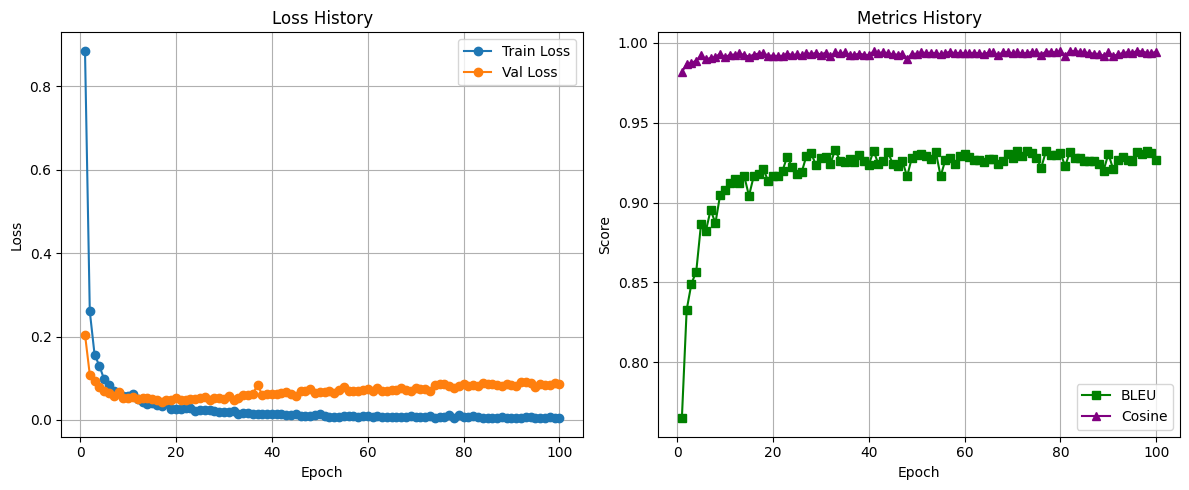


=== SAMPLE RECONSTRUCTIONS (BEST MODEL) ===
Input:  good beautiful negation / / make (no/not) do fear heart thing
Target: negation (no/not) do / make thing beautiful / good heart fear
Pred:   negation (no/not) do / make thing beautiful / good heart fear
------------------------------
Input:  cut temple chisel / adze stone brick deity god
Target: adze chisel cut stone brick temple god / deity
Pred:   adze chisel cut stone brick temple god / deity
------------------------------
Input:  carries     pellet     man     handle     basket     grain
Target: man carries basket handle grain pellet
Pred:   man carries basket handle grain pellet
------------------------------
Input:  temple peace altar above great god fire
Target: fire above peace altar god great temple
Pred:   fire above peace altar god great temple
------------------------------
Input:  man plow hoe pellet grain field servant
Target: hoe plow field grain pellet man servant
Pred:   hoe plow field grain pellet man servant
-------

In [4]:
import torch
import random
import pandas as pd
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from transformers import (
    BartTokenizer, 
    BartForConditionalGeneration, 
    get_linear_schedule_with_warmup
)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. CONFIGURATION & DIRECTORIES
# ==========================================
MODEL_NAME = "facebook/bart-base"
MAX_LEN = 32
BATCH_SIZE = 16
EPOCHS = 100
LEARNING_RATE = 5e-5
SAVE_DIR = "./best_model_checkpoint"

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

# ==========================================
# 1. DATA LOADING & PREPARATION
# ==========================================
# Assuming these variables exist in your environment. 
# Added fallbacks for script stability.

# Clean the inputs: Convert multiline strings to space-separated strings
original_shuffled = [s.replace("\n", " ").strip() for s in shuffled_sentences_raw]

# ==========================================
# 2. DATA AUGMENTATION
# ==========================================
print("Generating augmented data...")

def augment_data(ground_truth_list, num_augmentations=10):
    """
    Creates multiple shuffled versions of each ground truth sentence.
    """
    inputs = []
    targets = []
    
    for sentence in ground_truth_list:
        words = sentence.split()
        if len(words) <= 1:
            continue
            
        for _ in range(num_augmentations):
            shuffled_words = words.copy()
            random.shuffle(shuffled_words)
            inputs.append(" ".join(shuffled_words))
            targets.append(sentence)
            
    return inputs, targets

aug_inputs, aug_targets = augment_data(merged_ground_truth_sentences, num_augmentations=10)

all_inputs = aug_inputs + original_shuffled
all_targets = aug_targets + merged_ground_truth_sentences

df = pd.DataFrame({'input_text': all_inputs, 'target_text': all_targets})
print(f"Total dataset size after augmentation: {len(df)}")

# ==========================================
# 3. DATASET & DATALOADER
# ==========================================
class SentenceReconstructionDataset(Dataset):
    def __init__(self, tokenizer, data, max_len=32):
        self.tokenizer = tokenizer
        self.data = data
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        source = str(self.data.iloc[index]['input_text'])
        target = str(self.data.iloc[index]['target_text'])

        source_tok = self.tokenizer(
            source, 
            max_length=self.max_len, 
            padding='max_length', 
            truncation=True, 
            return_tensors='pt'
        )

        target_tok = self.tokenizer(
            target, 
            max_length=self.max_len, 
            padding='max_length', 
            truncation=True, 
            return_tensors='pt'
        )

        # Labels for BART: shift happens internally, but we set -100 for padding
        labels = target_tok['input_ids'].flatten()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids': source_tok['input_ids'].flatten(),
            'attention_mask': source_tok['attention_mask'].flatten(),
            'labels': labels
        }

# ==========================================
# 4. MODEL SETUP
# ==========================================
print(f"Loading {MODEL_NAME} model...")
tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)
model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Split Data
train_size = int(0.8 * len(df))
val_size = len(df) - train_size
train_indices, val_indices = random_split(range(len(df)), [train_size, val_size])

train_df = df.iloc[list(train_indices.indices)].reset_index(drop=True)
val_df = df.iloc[list(val_indices.indices)].reset_index(drop=True)

train_set = SentenceReconstructionDataset(tokenizer, train_df, max_len=MAX_LEN)
val_set = SentenceReconstructionDataset(tokenizer, val_df, max_len=MAX_LEN)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

# ==========================================
# 5. METRICS HELPER
# ==========================================
try:
    from sentence_transformers import SentenceTransformer
    sim_model = SentenceTransformer('all-MiniLM-L6-v2')
    calc_cosine = True
except ImportError:
    print("sentence-transformers not installed. Cosine similarity will be skipped.")
    calc_cosine = False

def calculate_metrics(predictions, references):
    chencherry = SmoothingFunction()
    bleu_scores = [sentence_bleu([ref.split()], pred.split(), smoothing_function=chencherry.method1) 
                   for pred, ref in zip(predictions, references)]
    avg_bleu = np.mean(bleu_scores)

    avg_cosine = 0.0
    if calc_cosine:
        pred_embeddings = sim_model.encode(predictions)
        ref_embeddings = sim_model.encode(references)
        cos_sims = cosine_similarity(pred_embeddings, ref_embeddings).diagonal()
        avg_cosine = np.mean(cos_sims)
    
    return avg_bleu, avg_cosine

# ==========================================
# 6. TRAINING LOOP
# ==========================================
history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'bleu': [], 'cosine': []}
best_val_loss = float('inf')

print("Starting training...")

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    total_train_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        total_train_loss += loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_train_loss = total_train_loss / len(train_loader)

    # --- VALIDATION ---
    model.eval()
    total_val_loss = 0
    predictions = []
    references = []
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_val_loss += outputs.loss.item()
            
            generated_ids = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=MAX_LEN)
            decoded_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            
            # Reset -100 to pad_token_id for proper decoding
            labels_to_decode = labels.clone()
            labels_to_decode[labels_to_decode == -100] = tokenizer.pad_token_id
            decoded_labels = tokenizer.batch_decode(labels_to_decode, skip_special_tokens=True)
            
            predictions.extend(decoded_preds)
            references.extend(decoded_labels)

    avg_val_loss = total_val_loss / len(val_loader)
    bleu, cosine = calculate_metrics(predictions, references)
    
    # --- CHECKPOINTING (BEST VERSION) ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        print(f"--> New best model found! Saving to {SAVE_DIR}...")
        # Using HuggingFace's recommended method instead of legacy torch.save
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
    
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['bleu'].append(bleu)
    history['cosine'].append(cosine)
    
    print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | BLEU: {bleu:.4f}")

# ==========================================
# 7. RESULTS & VISUALIZATION
# ==========================================
# Load the best model for final evaluation/visualization
print("Loading best model for final reporting...")
model = BartForConditionalGeneration.from_pretrained(SAVE_DIR).to(device)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['epoch'], history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['epoch'], history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss History')
plt.xlabel('Epoch'), plt.ylabel('Loss'), plt.legend(), plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['epoch'], history['bleu'], label='BLEU', marker='s', color='green')
if calc_cosine:
    plt.plot(history['epoch'], history['cosine'], label='Cosine', marker='^', color='purple')
plt.title('Metrics History')
plt.xlabel('Epoch'), plt.ylabel('Score'), plt.legend(), plt.grid(True)
plt.tight_layout()
plt.show()

print("\n=== SAMPLE RECONSTRUCTIONS (BEST MODEL) ===")
sample_indices = random.sample(range(len(predictions)), min(10, len(predictions)))
for i in sample_indices:
    print(f"Input:  {val_df.iloc[i]['input_text']}")
    print(f"Target: {references[i]}")
    print(f"Pred:   {predictions[i]}")
    print("-" * 30)

# Save logs
pd.DataFrame(history).to_csv('training_metrics.csv', index=False)
pd.DataFrame({'Input': val_df['input_text'], 'Target': references, 'Prediction': predictions}).to_csv('reconstruction_results.csv', index=False)
print(f"\nTraining complete. Best model saved in: {SAVE_DIR}")